# Исследование бизнес-показателей компании для приложения Procrastinate Pro+

**Цель исследования:**
1. Разобраться в причинах убыточности компании.
2. Оценить окупаемость рекламной кампании приложения по странам, устройствам и каналам привлечения пользователей.
3. Сформулировать рекомендации для рекламного отдела компании.

**Ход исследования:**
Для исследования нам предоставлено 3 файла `/datasets/visits_info_short.csv` - содержит данные о посещениях пользователей, `/datasets/orders_info_short.csv` - содержит данные о покупках пользователей, `/datasets/costs_info_short.csv` - содержит данные о рекламных расходах. Эти файлы нам предстоит проверить на наличие пропусков, дубликатов и ошибок.

Произведем общий обзор данных, приведем их в должный для проведения анализа вид, чтобы максимально исключить возможность искажения конечного результата исследования.

**Этапы исследования:**
- Загрузка и подготовка данных к анализу
- Задача функций для рассчета и визуализации бизнес-показателей
- Исследовательский анализ платящих пользователей и составление профилей пользователей
- Исследовательский анализ расходов на маркетинг и расчет общего САС
- Оценка окупаемости рекламы
- Выводы и рекомендации

### Загрузим данные и подготовим их к анализу

Импортируем необходимые библиотеки м выгрузим данные для анализа.

In [4]:
#импортируем необходимые библиотеки
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from matplotlib import pyplot as plt

In [5]:
#выгрузим данные для анализа
try:
    visits, orders, costs = (
        pd.read_csv('/datasets/visits_info_short.csv'),
        pd.read_csv('/datasets/orders_info_short.csv'),
        pd.read_csv('/datasets/costs_info_short.csv'),
    )
except:
    visits, orders, costs = (
        pd.read_csv('https://code.s3.yandex.net/datasets/visits_info_short.csv'),
        pd.read_csv('https://code.s3.yandex.net/datasets/orders_info_short.csv'),
        pd.read_csv('https://code.s3.yandex.net/datasets/costs_info_short.csv'),
    )

Создадим функцию для изучения данных в датафреймах.

In [6]:
#функция для изучения данных датафрейма
def show_info(df):
    display(df.head(5))
    print('----------')
    print(df.info())
    print('----------')
    print(df.isna().sum())
    print('----------')
    print(df.duplicated().sum())

Выведем наши датафреймы и изучим информацию по каждому из них. Посмотрим общую информацию, наличие пропусков и дубликатов на первый взгляд.

In [7]:
#выведем информацию по датасету visits
show_info(visits)

,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB
None
----------
User Id          0
Region           0
Device           0
Channel          0
Session Start    0
Session End      0
dtype: int64
----------
0


In [8]:
#выведем информацию по датасету orders
show_info(orders)

,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB
None
----------
User Id     0
Event Dt    0
Revenue     0
dtype: int64
----------
0


In [9]:
#выведем информацию по датасету costs
show_info(costs)

,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   Channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB
None
----------
dt         0
Channel    0
costs      0
dtype: int64
----------
0


Изучив информацию о датафреймах, видим следующее: 
- во всех трех датафреймах отсутствуют пропуски и дубликаты, что хорошо для анализа; 
- в названиях колонок необходимо заменить регистр на нижний и произвести замену пробелов на знак нижнего подчеркивания "_" для более удобного для анализа синтаксиса; 
- в ряде колонок с датами произвести замену типа данных с object на datetime.

Приступим к работе с названиями колонок. Нам необходимо привести названия к нижнему регистру и заменить пробелы на знак нижнего подчеркивания. Для этого создадим функцию.

In [10]:
#создадим функцию для замены названий колонок
def fix(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    return df

In [11]:
#применим функцию к нашим датафреймам
visits = fix(visits)
orders = fix(orders)
costs = fix(costs)

Приступим к замене типов данных. 

In [12]:
#переведем колонки в необходимый тип данных
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])
orders['event_dt'] = pd.to_datetime(orders['event_dt'])
costs['dt'] = pd.to_datetime(costs['dt']).dt.date

Проверим сделанные нами изменения. Для этого снова выведем общую информацию по датафреймам.

In [13]:
#выведем информацию об измененных датафреймах
print(visits.info())
print(orders.info())
print(costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  object        
 2   device         309901 non-null  object        
 3   channel        309901 non-null  object        
 4   session_start  309901 non-null  datetime64[ns]
 5   session_end    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[ns]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage:

Обработка названий колонок и замена типов данных прошла успешно.

Поскольку явных дубликатов не выявлено, попробуем проверить есть ли неявные дубликаты в колонках `region`, `device`, `channel`.

In [14]:
#поверяем неявные дубликаты в столбце region таблицы visits 
print(visits['region'].unique())

['United States' 'UK' 'France' 'Germany']


In [15]:
#поверяем неявные дубликаты в столбце device таблицы visits
print(visits['device'].unique())

['iPhone' 'Mac' 'Android' 'PC']


In [16]:
#поверяем неявные дубликаты в столбце channel таблицы visits
print(visits['channel'].unique())

['organic' 'TipTop' 'RocketSuperAds' 'YRabbit' 'FaceBoom' 'MediaTornado'
 'AdNonSense' 'LeapBob' 'WahooNetBanner' 'OppleCreativeMedia'
 'lambdaMediaAds']


In [17]:
#поверяем неявные дубликаты в столбце channel таблицы costs
print(costs['channel'].unique())

['FaceBoom' 'MediaTornado' 'RocketSuperAds' 'TipTop' 'YRabbit'
 'AdNonSense' 'LeapBob' 'OppleCreativeMedia' 'WahooNetBanner'
 'lambdaMediaAds']


Неявные дубликаты также отсутствуют.

**Вывод по разделу:**
При подготовке данных к проведению анализа, пропусков, а также явных и неявных дубликатов обнаружено не было, что в разы облегчает наше исследование и минимизирует возможность искажения результатов. При этом, для удобства и соблюдения синтаксиса Python, произвели обработку названий колонок, приведя их к нижнему регистру и заменив пробелы между словами на символ "_". Также провели замену типов данных в колонках `session_start`, `session_end`, `event_dt` и `dt` с *object* на *datetime*.

### Задаем функции для расчёта и анализа LTV, ROI, удержания и конверсии.

Компания-заказчик терпит убытки от созданного ей продукта - развлекательное приложение `'Procrastinate Pro+'` -, несмотря на огромные вложения в рекламу. 

Для того, чтобы разобраться в причинах вышесказанного, нам необходимо изучить следующие показатели:
- Retention Rate - удержание пользователей,
- Conversion Rate - конверсия пользователей,
- LTV - время жизни пользователей,
- CAC - стоимость привлечения одного клиента,
- ROI - окупаемость инвестиций (на сколько процентов LTV превысил CAC).

Напишем соответствующие функции для расчета необходимых бизнес-показателей, а также функции для их визуализации.

In [18]:
#функция для создания профилей пользователей
def get_profiles(sessions, orders, ad_costs):

    # находим параметры первых посещений
    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['dt'] = profiles['first_ts'].dt.date
    profiles['month'] = profiles['first_ts'].astype('datetime64[M]')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

In [19]:
#функция для расчета удержания пользователей (Retention Rate)
def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [20]:
#функция для расчета конверсии (Conversion Rate)
def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [21]:
#Функция для расчета LTV и ROI
def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC, 
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    ) 

Напишем функции для визуализации этих метрик.

In [22]:
#функция для сглаживания фрейма
def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df 

In [23]:
#функция для визуализации удержания пользователей 
def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    
    plt.tight_layout()
    plt.show() 

In [24]:
#функция для визуализации конверсии пользователей
def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

In [25]:
#функция для визуализации LTV и ROI
def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

**Вывод по разделу:**
В данном разделе мы обозначили необходимые бизнес-показатели, которые помогут провести исследование и выяснить причины проблемы убыточности компании. Также мы задали функции для создания профилей пользователей, расчета бизнес-показателей (Retention Rate, Conversion Rate, LTV, ROI) и их визуализации.

### Исследовательский анализ данных

В ходе исследовательского анализа данных мы:
- Составим профили пользователей. Определим минимальную и максимальную даты привлечения пользователей.
- Выясним, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей. Построим таблицу, отражающую количество пользователей и долю платящих из каждой страны.
- Узнаем, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Построим таблицу, отражающую количество пользователей и долю платящих для каждого устройства.
- Изучим рекламные источники привлечения и определите каналы, из которых пришло больше всего платящих пользователей. Построим таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.

#### Составляем профили пользователей

Составим таблицу с профилями пользователей и определим минимальную и максимальную даты привлечения пользователей.

In [26]:
#получаем профили пользователей
profiles = get_profiles(visits, orders, costs)
display(profiles.head(5))

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769


In [27]:
#определим минимальную дату привлечения пользователей
min_dt = profiles['dt'].min()
#определим максимальную дату привлечения пользователей
max_dt = profiles['dt'].max()
print(f'Минимальная дата привлечения пользователей: {min_dt}')
print(f'Максимальная дата привлечения пользователей: {max_dt}')

Минимальная дата привлечения пользователей: 2019-05-01
Максимальная дата привлечения пользователей: 2019-10-27


Обратившись к написаной ранее функции, получили таблицу с профилями пользователей. Определили, что *минимальная* дата привлечения пользователей - `1 мая 2019 года`, а *максимальная* дата - `27 октября 2019 года`, что также соответствует с ТЗ.

#### Определяем количество пользователей и долю платящих по странам

Орпеделим, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей.

In [28]:
#строим таблицу с количеством платящих и неплатящих пользователей, а также с долей платящих пользователей по регионам
region_profiles = (profiles.groupby('region')
                   .agg({'user_id': 'nunique', 'payer': 'sum'})
                   .sort_values(by='user_id', ascending=False)
                  )
region_profiles['Доля платящих пользователей'] = round(region_profiles['payer'] / region_profiles['user_id'] * 100, 2)
region_profiles = region_profiles.rename(columns={'user_id': 'Количество пользователей', 'payer': 'Количество платящих пользователей'})
region_profiles

,Количество пользователей,Количество платящих пользователей,Доля платящих пользователей
region,,,
United States,100002,6902,6.90
UK,17575,700,3.98
France,17450,663,3.80
Germany,14981,616,4.11


Пользователи приходят в приложение из Франции, Германии, Великобритании и США. 

Несомненную лидирующую позицию по количеству пользователей занимает США - оттуда пришло целых 100002 пользователя. Меньше всего пользователей пришло из Германии - 14981. 

По доле платящих пользователей также в лидерах остается США с долей 6,9%, а оутсайдером является Франция с долей 3,8%.

#### Определим количество пользователей и долю платящих для каждого устройства

Определим какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи.

In [29]:
#строим таблицу с количеством платящих и неплатящих пользователей, а также с долей платящих пользователей по устройствам
device_profiles = (profiles.groupby('device')
                   .agg({'user_id': 'nunique', 'payer': 'sum'})
                   .sort_values(by='user_id', ascending=False)
                  )
device_profiles['Доля платящих пользователей'] = round(device_profiles['payer'] / device_profiles['user_id'] * 100, 2)
device_profiles = device_profiles.rename(columns={'user_id': 'Количество пользователей', 'payer': 'Количество платящих пользователей'})
device_profiles

,Количество пользователей,Количество платящих пользователей,Доля платящих пользователей
device,,,
iPhone,54479,3382,6.21
Android,35032,2050,5.85
PC,30455,1537,5.05
Mac,30042,1912,6.36


Среди пользователей приложения Procrastinate Pro+ обладатели устройств Android, Mac, PC и iPhone.

Большая часть пользователей использует устройства iPhone - таких пользователей 54479, что неудевительно, так как большая часть пользователей из США, где большая часть населения является обладателями iPhone. Наименьшее и примерно равное количество пользователей с устройствами PC и Mac - 30455 и 30042 пользователей соответственно.

По доли платящих лидируют пользователи Mac - 6,36%. Пользователи PC идут на последнем месте с долей 5,05%.

#### Определим количество пользователей и долю платящих для каждого канала привлечения

Изучим рекламные источники привлечения и определим каналы, из которых пришло больше всего платящих пользователей, а также их долю.

In [30]:
#строим таблицу с количеством платящих и неплатящих пользователей, а также с долей платящих пользователей по каналам привлечения
channel_profiles = (profiles.groupby('channel')
                   .agg({'user_id': 'nunique', 'payer': 'sum'})
                   .sort_values(by='user_id', ascending=False)
                  )
channel_profiles['Доля платящих пользователей'] = round(channel_profiles['payer'] / channel_profiles['user_id'] * 100, 2)
channel_profiles = channel_profiles.rename(columns={'user_id': 'Количество пользователей', 'payer': 'Количество платящих пользователей'})
channel_profiles

,Количество пользователей,Количество платящих пользователей,Доля платящих пользователей
channel,,,
organic,56439,1160,2.06
FaceBoom,29144,3557,12.20
TipTop,19561,1878,9.60
OppleCreativeMedia,8605,233,2.71
LeapBob,8553,262,3.06
WahooNetBanner,8553,453,5.30
RocketSuperAds,4448,352,7.91
MediaTornado,4364,156,3.57
YRabbit,4312,165,3.83


Всего можем выделить 11 каналов привлечения пользователей.

Больше всего привлеклось органических пользователей - их 56439. Привлечение таких пользователей бесплатно для компании, так как они находят приложение сами. При этом доля платящих среди органических пользователей самая низкая - около 2%. 

На втором месте по количеству привлеченных пользователей канал FaceBoom. С этого канала было привлечено 29144 пользователя. Также доля платящих пользователей привлеченных с FaceBoom самая высокая и составляет 12,2%.

Канал lambdaMediaAds привлек нам наименьшее количество пользователей (2149), при этом стоит отметить, что доля платящих пользователей привлеченных с этого канала относительно высока.

**Вывод по разделу:**
- Минимальная дата привлечения пользователей - `1 мая 2019 года`, а максимальная дата - `27 октября 2019 года`.
- Пользователи приходят в приложение из *Франции*, *Германии*, *Великобритании* и *США*. Лидирующую позицию по количеству пользователей занимает *США* - оттуда пришло 100002 пользователя. Меньше всего пользователей пришло из *Германии* - 14981. По доле платящих пользователей также в лидерах остается *США* с долей 6,9%, а оутсайдером является *Франция* с долей 3,8%.
- Большая часть пользователей приложения использует устройства *iPhone* - таких пользователей 54479. Наименьшее и примерно равное количество пользователей с устройствами *PC и Mac* - 30455 и 30042 пользователей соответственно. По доли платящих лидируют пользователи *Mac* - 6,36%. Пользователи *PC* идут на последнем месте с долей 5,05%.
- Компания использовала 11 каналов привлечения. Больше всего привлеклось *органических пользователей* - их 56439. На втором месте по количеству привлеченных пользователей канал *FaceBoom*. Доля платящих пользователей привлеченных с *FaceBoom* самая высокая.

### Маркетинг

В этом шаге мы:
- Посчитаем общую сумму расходов на маркетинг.
- Выясним, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.
- Построим график с визуализацией динамики изменения расходов во времени по неделям по каждому источнику. Затем на другом графике визуализируем динамику изменения расходов во времени по месяцам по каждому источнику.
- Узнаем, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника.

#### Общая сумма расходов на маркетинг

Произведем расчет общей суммы расходов на маркетинг.

In [31]:
marketing_sum = round(profiles['acquisition_cost'].sum(), 1)
print(f'Общая сумма расходов на маркетинг составила {marketing_sum} денежных единиц.')

Общая сумма расходов на маркетинг составила 105497.3 денежных единиц.


#### Сумма расходов на маркетинг по рекламным источникам

Посмотрим как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.

In [32]:
#выведем распределение расходов на маркетинг по рекламным источникам с помощью таблицы
channel_marketing_sum = (profiles.groupby('channel')
                         .agg({'acquisition_cost': 'sum'})
                         .sort_values(by='acquisition_cost', ascending=False)
                         .rename(columns={'acquisition_cost': 'Расходы на рекламу'})
                        )
channel_marketing_sum['Доля от общих расходов'] = round((channel_marketing_sum['Расходы на рекламу'] / marketing_sum) * 100, 1)
channel_marketing_sum

,Расходы на рекламу,Доля от общих расходов
channel,,
TipTop,54751.30,51.9
FaceBoom,32445.60,30.8
WahooNetBanner,5151.00,4.9
AdNonSense,3911.25,3.7
OppleCreativeMedia,2151.25,2.0
RocketSuperAds,1833.00,1.7
LeapBob,1797.60,1.7
lambdaMediaAds,1557.60,1.5
MediaTornado,954.48,0.9


Для наглядности построим график распределения расходов на маркетинг по рекламным источникам.

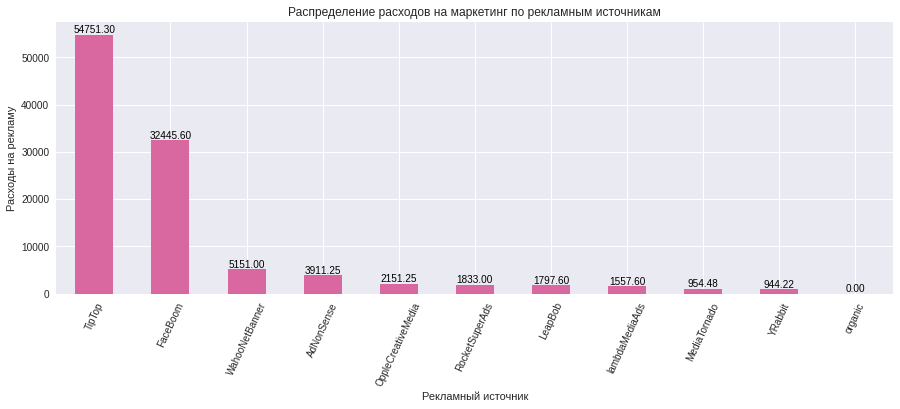

In [36]:
#график распределения расходов на маркетинг по рекламным источникам
plt.style.use('seaborn')
ax = channel_marketing_sum['Расходы на рекламу'].plot(kind='bar', figsize=(15, 5), grid=True, color= '#d968a0')
plt.title('Распределение расходов на маркетинг по рекламным источникам')
plt.xlabel('Рекламный источник')
plt.ylabel('Расходы на рекламу')
plt.tick_params(axis='x', rotation=65)

# Добавляем текстовую подпись над каждым столбцом
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
    
plt.show()

Можем обратить внимание, что большая часть финансов на рекламу была вложена в каналы привлечения *TipTop* и *FaceBoom* - 51.9% и 30.8% соответственно. Меньше всего затрат было на канал *YRabbit* - 0.9%.

Затраты на органических пользователей всегда будут равны 0, так как это пользователи, которые скачали приложение самостоятельно. 

#### Динамики изменения расходов на маркетинг во времени по неделям и месяцам по каждому источнику

Для построения графика динамики по неделям, необходимо сначала выделить из даты начала сессии неделю.

In [31]:
#таблица динамики расходов по неделям
prof_copy = profiles.copy()
prof_copy['week'] = prof_copy['first_ts'].dt.isocalendar().week
channel_marketing_week = prof_copy.pivot_table(index='week', columns='channel', values='acquisition_cost', aggfunc='sum')

channel_marketing_week

channel,AdNonSense,FaceBoom,LeapBob,MediaTornado,OppleCreativeMedia,RocketSuperAds,TipTop,WahooNetBanner,YRabbit,lambdaMediaAds,organic
week,,,,,,,,,,,
18,211.05,535.7,16.80,38.64,24.00,99.450,347.0,49.2,52.20,81.6,0.0
19,273.00,750.2,31.71,61.68,34.50,139.230,470.0,92.4,75.90,103.2,0.0
20,265.65,755.7,26.67,59.04,27.50,138.060,454.0,90.0,69.30,90.4,0.0
21,266.70,722.7,26.67,50.16,34.25,131.040,801.8,79.2,65.40,119.2,0.0
22,202.65,1208.9,65.52,36.96,81.75,97.695,1421.2,179.4,49.80,83.2,0.0
23,102.90,1081.3,66.99,27.60,79.50,76.050,1223.6,196.8,25.80,35.2,0.0
24,96.60,1042.8,52.29,29.76,71.50,63.180,1121.0,166.2,17.46,45.6,0.0
25,141.75,1280.4,68.46,32.16,79.75,80.730,1474.4,201.6,22.14,40.0,0.0
26,148.05,1647.8,99.75,40.56,107.00,78.260,2343.6,285.0,27.90,59.2,0.0


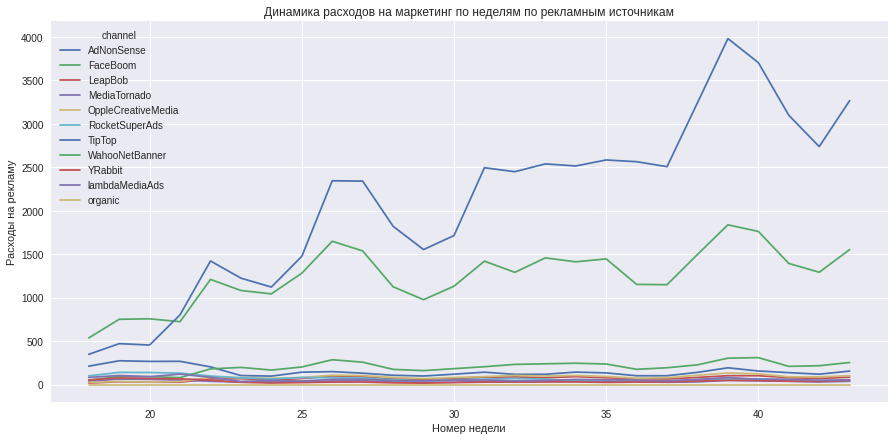

In [32]:
#график распределения расходов на маркетинг по неделям
plt.style.use('seaborn')
channel_marketing_week.plot(figsize=(15, 7), grid=True)
plt.title('Динамика расходов на маркетинг по неделям по рекламным источникам')
plt.xlabel('Номер недели')
plt.ylabel('Расходы на рекламу')

plt.show()

Расходы у всех каналов, за исключением TipTop и FaceBoom, из недели в неделю идут примерно одинаково ровно. Компания не тратит много на рекламу в данных источниках. 

Расходы на привлечение пользователей из каналов TipTop и FaceBoom с 18 по 26 неделю увеличиваются, далее снижаются до 29 недели, потом снова увеличиваются и достигают своего пика на 39 неделе.

Теперь посмотрим динамику расходов на рекламу по месяцам.

In [33]:
##таблица динамики расходов по месяцам
channel_marketing_month = profiles.pivot_table(index='month', columns='channel', values='acquisition_cost', aggfunc='sum')

channel_marketing_month

channel,AdNonSense,FaceBoom,LeapBob,MediaTornado,OppleCreativeMedia,RocketSuperAds,TipTop,WahooNetBanner,YRabbit,lambdaMediaAds,organic
month,,,,,,,,,,,
2019-05-01,1169.70,3524.4,140.28,238.56,169.75,577.980,2981.0,418.8,299.70,458.4,0.0
2019-06-01,538.65,5501.1,314.58,138.00,370.00,325.715,6675.6,921.0,106.20,199.2,0.0
2019-07-01,504.00,5294.3,313.53,138.48,366.50,252.070,8410.2,851.4,97.38,219.2,0.0
2019-08-01,579.60,6274.4,369.81,154.56,439.25,253.110,11202.0,1040.4,124.74,220.0,0.0
2019-09-01,581.70,6114.9,343.98,144.72,427.75,218.400,13232.5,977.4,152.79,247.2,0.0
2019-10-01,537.60,5736.5,315.42,140.16,378.00,205.725,12250.0,942.0,163.41,213.6,0.0


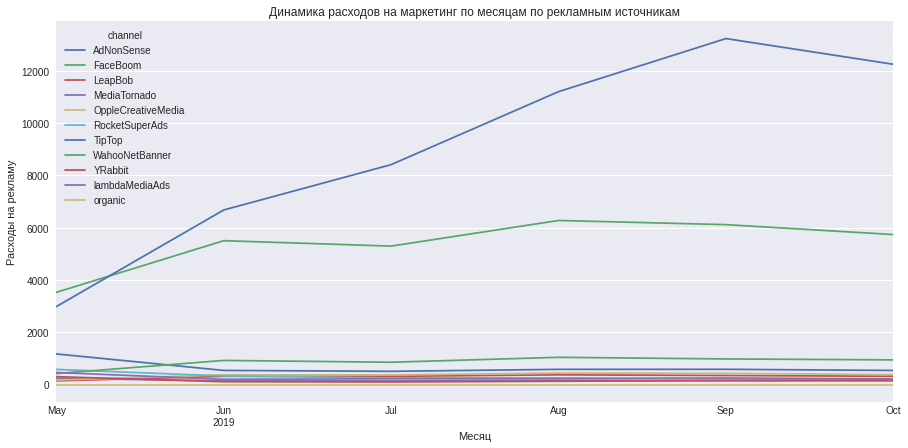

In [34]:
#график распределения расходов на маркетинг по месяцам
plt.style.use('seaborn')
channel_marketing_month.plot(figsize=(15, 7), grid=True)
plt.title('Динамика расходов на маркетинг по месяцам по рекламным источникам')
plt.xlabel('Месяц')
plt.ylabel('Расходы на рекламу')

plt.show()

По такому графику не совсем понятна динамика, попробуем провести сглаживание.

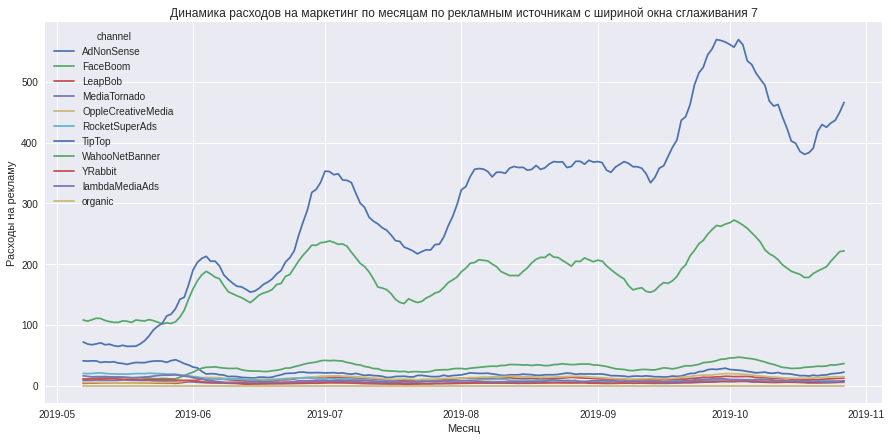

In [35]:
rolling_channel_marketing = profiles.pivot_table(index='dt', columns='channel', values='acquisition_cost', aggfunc='sum')

for column in rolling_channel_marketing.columns.values:
        rolling_channel_marketing[column] = rolling_channel_marketing[column].rolling(7).mean()
# строим график
rolling_channel_marketing.plot(figsize=(15, 7), grid=True)
plt.title('Динамика расходов на маркетинг по месяцам по рекламным источникам с шириной окна сглаживания 7')
plt.xlabel('Месяц')
plt.ylabel('Расходы на рекламу')

plt.show() 

Теперь видим более наглядную картину, которая похожа на предыдущий график динамики расходов по неделям. 

Наблюдаем пик расходов у каналов *TipTop* и *FaceBoom* в октябре 2019 года, что совпадает с 39 неделей проведения рекламной кампании, который мы обнаружили на графике выше.

**Вывод:** Динамика маркетинговых расходов во времени остается практически неизменной по большинству каналов привлечения. Исключения составляют каналы `TipTop` и `FaceBoom`. Их динамика сильно варьируется с тенденцией к повышению. Пики по данным каналам наблюдаем в районе 22 недели, что совпадает с началом июня 2019 года; в районе 26 недели, что совпадает с началом июля 2019 года; и самый большой пик приходится на 39 неделю, что совпадает с концом ноября - началом октября 2019 года.

#### Средняя стоимость привлечения одного пользователя (CAC) из каждого источника

`CAC` (Customer Acquisition Cost) — стоимость привлечения одного клиента. Стоимость, в которую компании обходится каждый новый клиент. В сущности, CAC — это инвестиции в маркетинг.

Для начала произведем расчет общего среднего САС без разбивки по характеристикам.

In [36]:
#считаем общий САС
cac = profiles['acquisition_cost'].mean().round(2)
print(f'Общий САС без разбивки по характеристикам составил {cac} денежных единиц.')

Общий САС без разбивки по характеристикам составил 0.7 денежных единиц.


Произведем расчет средней стоимости привлечения одного пользователя из каждого источника.

In [37]:
#расчет средней стоимости привлечения одного пользователя из каждого источника
cac_by_channel = (
            profiles.groupby('channel')
            .agg({'acquisition_cost': 'mean'})
            .round(2)
            .sort_values(by='acquisition_cost', ascending=False)
            .rename(columns={'acquisition_cost': 'CAC канала привлечения'})
        )
cac_by_channel

,CAC канала привлечения
channel,
TipTop,2.80
FaceBoom,1.11
AdNonSense,1.01
lambdaMediaAds,0.72
WahooNetBanner,0.60
RocketSuperAds,0.41
OppleCreativeMedia,0.25
MediaTornado,0.22
YRabbit,0.22


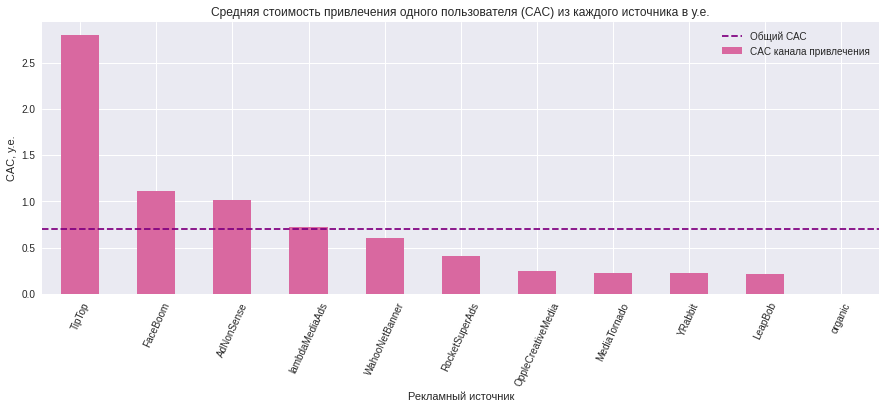

In [38]:
#график средней стоимости привлечения одного пользователя из каждого источника
plt.style.use('seaborn')
cac_by_channel.plot(kind='bar', figsize=(15, 5), grid=True, color= '#d968a0')
plt.title('Средняя стоимость привлечения одного пользователя (CAC) из каждого источника в у.е.')
plt.xlabel('Рекламный источник')
plt.ylabel('CAC, у.е.')
plt.tick_params(axis='x', rotation=65)
plt.axhline(y=cac, color='purple', linestyle='--', label='Общий САС')
plt.legend()
plt.show()

**Вывод:** Общий САС без разбивки по характеристикам составил 1.13 денежных единиц. Самая высокая средняя стоимость привлечения пользователей у канала `TipTop` - в среднем 2,8 денежных единиц. Более чем в 2 раза ниже стоимость привлечения на канале `FaceBoom` - 1,1 денежная единица. Что примечательно - эта платформа приносит компании больше пользователей, чем более дорогостоящая `TipTop`. Возможно, стоит уделить платформе `FaceBoom` больше внимания?.. Меньше всего стоимость привлечения пользователей на платформах `MediaTornado` и `LeapBob` - 0,21 денежная единица.
Как всегда замыкает наш топ бесценная группа "органиков"!!!
В общем, стоимость привлечения пользователей в приложение у всех каналов ниже средней, кроме канала `TipTop` - он является самым дорогим.

**Выводы по разделу:**
- Общая сумма расходов на маркетинг составила `105497.3` денежных единиц.
- Большая часть финансов на рекламу была вложена в каналы привлечения `TipTop` и `FaceBoom` - 51,9% и 30,8% соответственно. Меньше всего затрат было на канал YRabbit - 0,9%.
- Динамика маркетинговых расходов во времени остается практически неизменной по большинству каналов привлечения. Исключения составляют каналы `TipTop` и `FaceBoom`. Их динамика сильно варьируется с тенденцией к повышению. Пики по данным каналам наблюдаем в районе 22 недели, что совпадает с началом июня 2019 года; в районе 26 недели, что совпадает с началом июля 2019 года; и самый большой пик приходится на 39 неделю, что совпадает с концом ноября - началом октября 2019 года.
- Общий САС без разбивки по характеристикам составил 1.13 денежных единиц. Самая высокая средняя стоимость привлечения пользователей у канала `TipTop` - в среднем 2,8 денежных единиц. Более чем в 2 раза ниже стоимость привлечения на канале `FaceBoom` - 1,1 денежная единица. Меньше всего стоимость привлечения пользователей на платформах `MediaTornado` и `LeapBob` - 0,21 денежная единица. В общем, стоимость привлечения пользователей в приложение у всех каналов ниже средней, кроме канала `TipTop` - он является самым дорогим.

### Оценка окупаемости рекламы

В данном шаге мы:
- Проанализируем окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проверим конверсию пользователей и динамику её изменения. То же самое сделаем с удержанием пользователей. Построим и изучим графики конверсии и удержания.
- Проанализируем окупаемость рекламы с разбивкой по устройствам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируем окупаемость рекламы с разбивкой по странам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируем окупаемость рекламы с разбивкой по рекламным каналам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.

#### Анализ окупаемости рекламы

Для начала оценим общую ситуацию — посмотрим на окупаемость рекламы. Сделаем расчет показателей LTV и ROI, произведем их визуализацию, испльзуя функции `get_ltv()` и `plot_ltv_roi()`.

Зададим момент и горизонт анализа данных. Текущей датой анализа будем считать 1 ноября 2019 года, горизонт анализа - 2 недели (14 дней). Также исключим из анализа органических пользователей, так как нам необходимо рассмотреть пользователей, привлеченных рекламной кампанией.

In [39]:
#зададим момент анализа - 1 ноября 2019
observation_date = datetime(2019,11,1).date()
#задаем горизонт анализа - 14 дней
horizon_days = 14
#исключаем органических пользователей
profiles = profiles.query('channel != "organic"')

Произведем расчет LTV и ROI и построим графики.

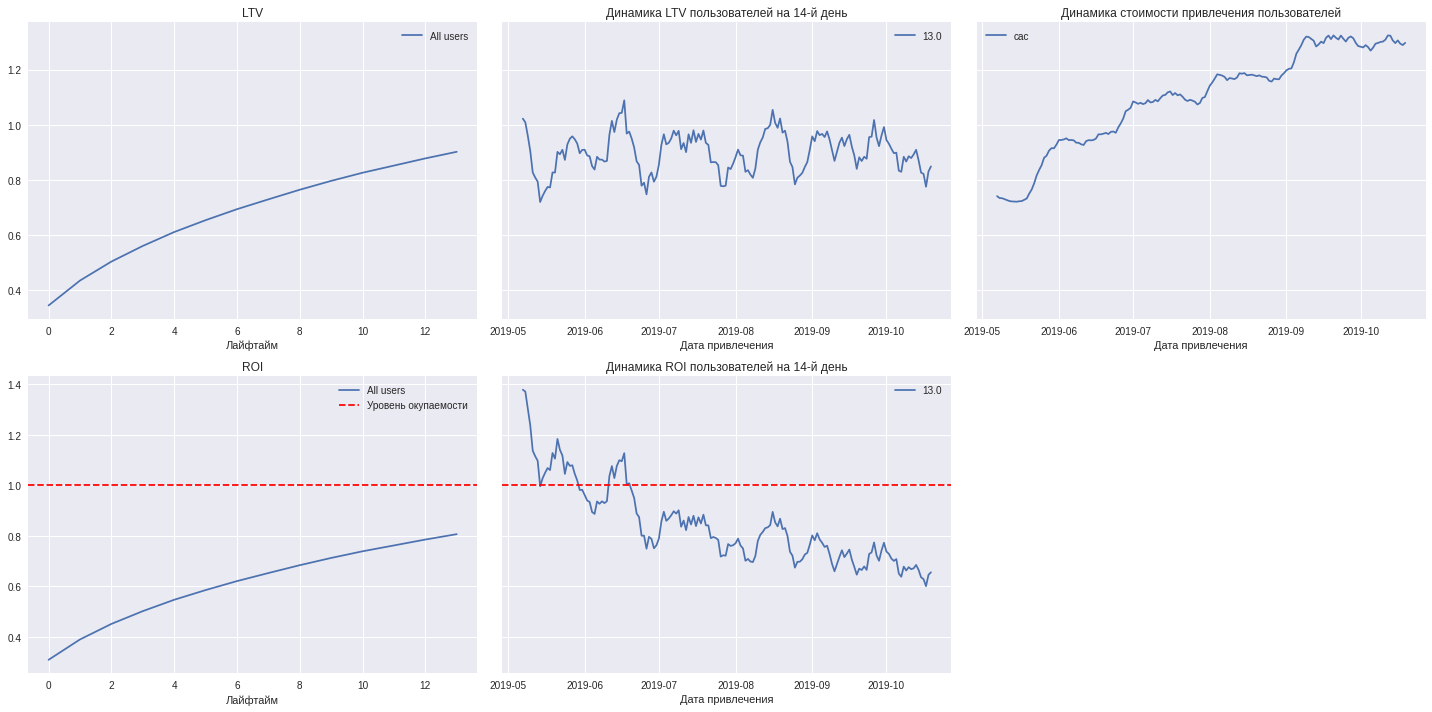

In [40]:
#посчитаем LTV и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles, orders, observation_date, horizon_days)
#строим графики динамики LTV, CAC и ROI
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

**Вывод:** Анализируя графики, можно сказать, что:
- За 2 недели рекламной кампании ROI так и не превысил 100%. В конце второй недели *ROI составил около 80%*, что говорит о том, что *реклама не окупается*. Динамика ROI начинает стабильно снижаться примерно с июня, как раз в период подъема бюджета на маркетинг.
- *С мая по июнь CAC резко поднимается* и дальше продолжает плавный подъем расходов на рекламу.
- LTV пользователей с мая по ноябрь варьируется примерно от 0,7 до 1,1, но *в целом достаточно стабилен*. Исходя из этого, можно сказать, что дело не в качестве пользователей.

#### Конверсия и удержание пользователей и динамика их изменения

Посчитаем `конверсию` пользователей и ее динамику, а также визуализируем ее. Для этого вызовем функции `get_conversion()` и `plot_conversion()`.

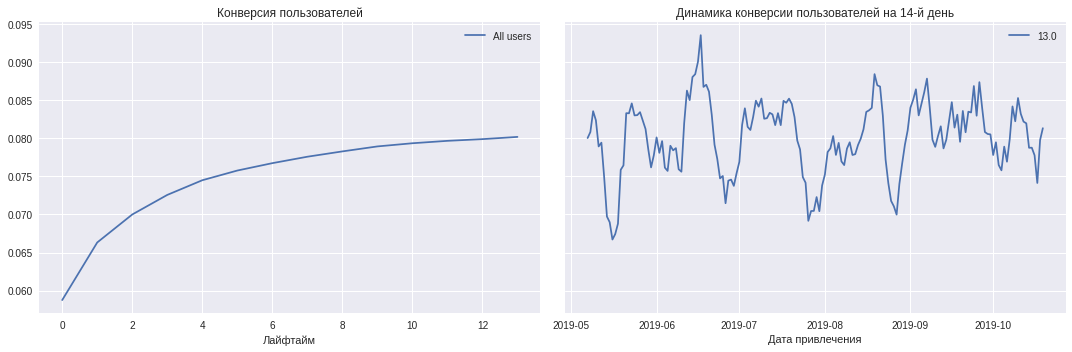

In [41]:
# рассчитываем конверсию и ее динамику
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles, orders, observation_date, horizon_days)
#остроим графики
plot_conversion(conversion_grouped, conversion_history, horizon_days)

Исходя из графиков, пользователи приложения плавно конвертируются с 6% до 8% за 2 недели. Темп конверсии не очень вдохновляющий.

Теперь посмотрим на удержание пользователей. Вызовем функции `get_retention()` и `plot_retention()`, чтобы рассчитать и отразить на графиках этот показатель.

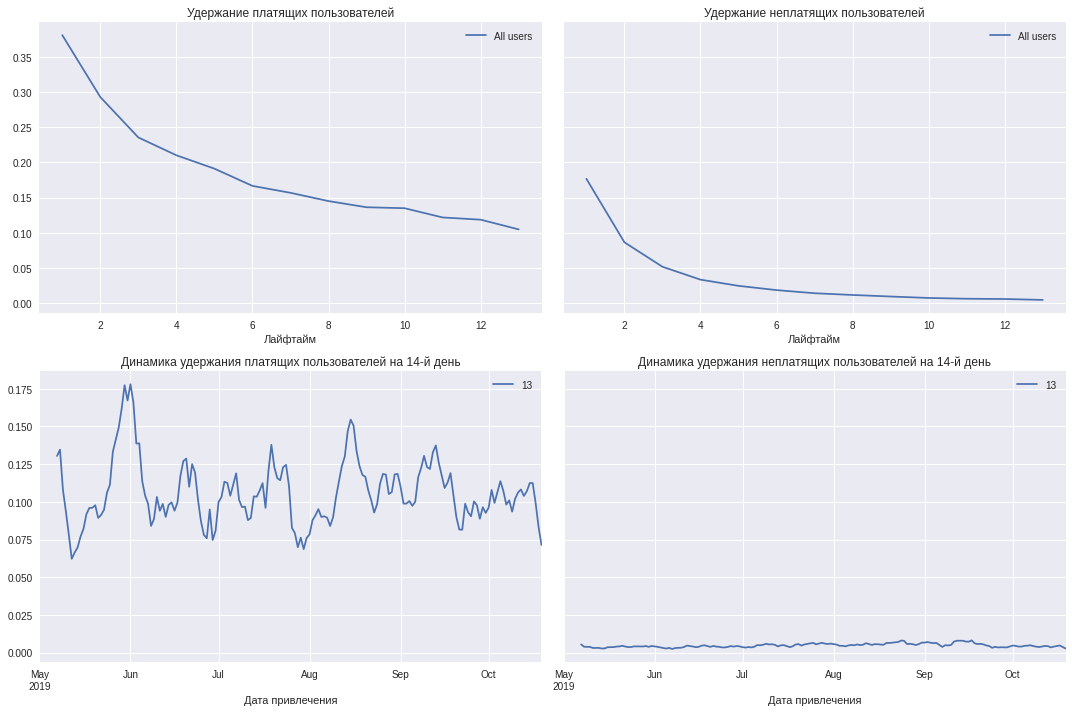

In [42]:
#расчитываем удержание пользователей
retention_raw, retention_grouped, retention_history = get_retention(profiles, visits, observation_date, horizon_days)
#строим графики
plot_retention(retention_grouped, retention_history, horizon_days) 

Удержание платящих пользователей выше, чем неплатящих на протяжении всего периода исследования. Активность платящих пользователей в отличие от неплатящих очень хорошо отражена на графиках динамики. У неплатящих пользователей показатель динамики близок к 0. 

**Выводы:**
- За 2 недели конверсия всех пользователей так и не превысила 80%. Динамика конверсии в целом стабильна. Темп конверсии средний.
- Коэффициент удержания платящих пользователей стабильно выше, чем у неплатящих, от начала и до конца исследуемого периода, причем примерно в 2 раза. Платящие пользователи с большей вероятностью и далее останутся в приложении, в то время как неплатящие скорее всего уйдут. Активность платящих пользователей в отличие от неплатящих очень хорошо отражена на графиках динамики. У неплатящих пользователей показатель динамики близок к 0.

#### Окупаемость рекламы с разбивкой по устройствам

Чтобы разобраться в причинах неокупаемости рекламы, проведем более детальных анализ показателей по характеристикам пользователей. Для начала посмотрим окупаемость рекламы по устройствам.

Расчитаем LTV, CAC, ROI и их динамику с разбивкой по устройствам. Пердадим параметру `dimensions` столбец `device`.

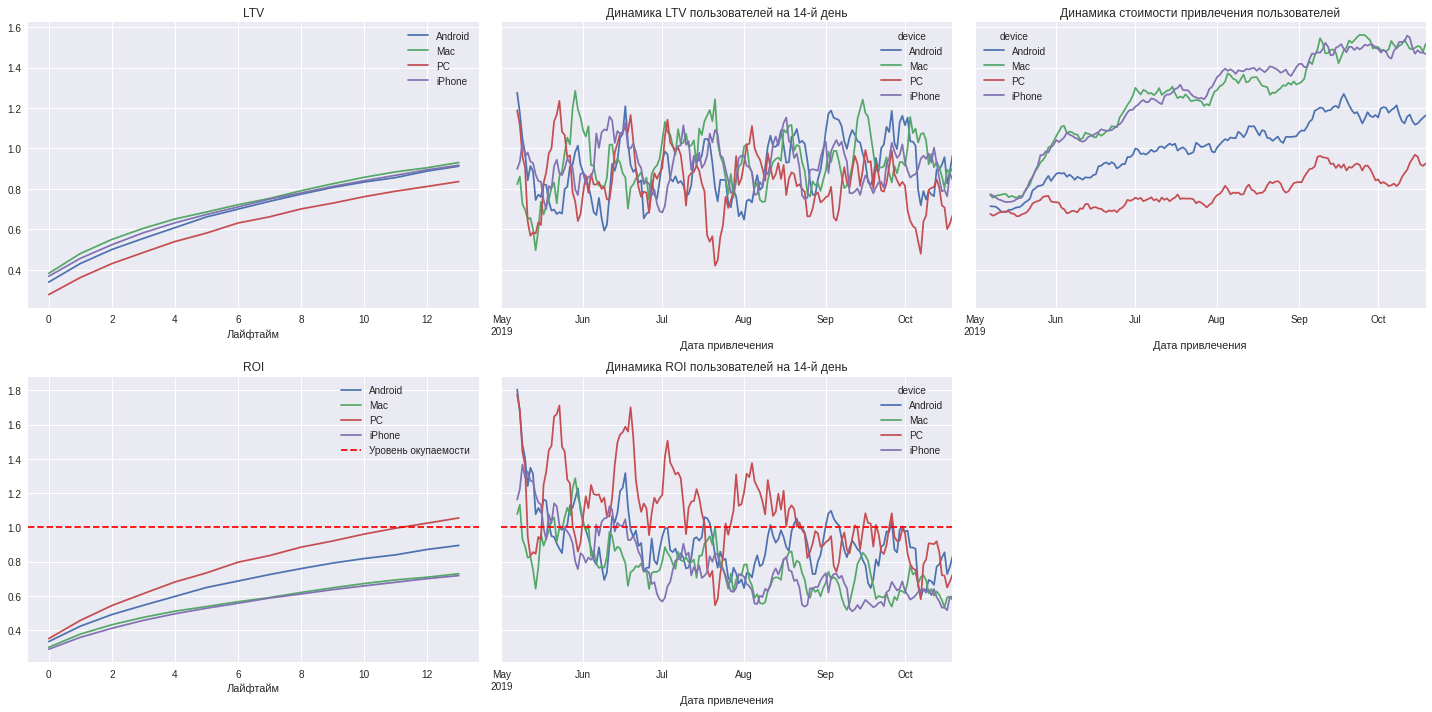

In [43]:
#посчитаем LTV и ROI с разбивкой по устройствам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles, orders, observation_date, horizon_days, dimensions=['device'])
#построим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

Коэффициент LTV у пользователей PC заметно ниже, чем у других утройств. К концу 2 недели LTV достигает значения примерно 0,8 - 0,9.

Динамика LTV варьируется в диапазоне 0,4 - 1,3. В разные периоды динамика пользователей PC склонна к снижению, что подтверждает и предыдущий график.

Самая высокая динамика стоимости привлечения (САС) у пользователей iPhone и Mac. Чуть ниже динамика САС у пользователей Android. Самая низкая, как и предполагалось, у пользователей PC.

Анализируя окупаемость рекламы (ROI), наблюдаем достаточно примечательную и неожиданную картину: не окупается реклама ни на одном устройстве, за исключением PC. Реклама для пользователей PC окупается на 11 день, хотя динамика стоимости привлечения пользователей говорит об обратном.

В общем динамика ROI в мае-июне кажется более "окупаемой", чем с сентября. Динамика окупаемости пользователей PC имеет более широкий диапазон, чем у пользователей Android, Mac и iPhone. В период с мая по сентябрь окупаемость пользователей PC имеет успех по сравнению с другими устройствами, но с сентября также снижается.

Посчитаем и визуализируем конверсию пользователей с разбивкой по устройствам.

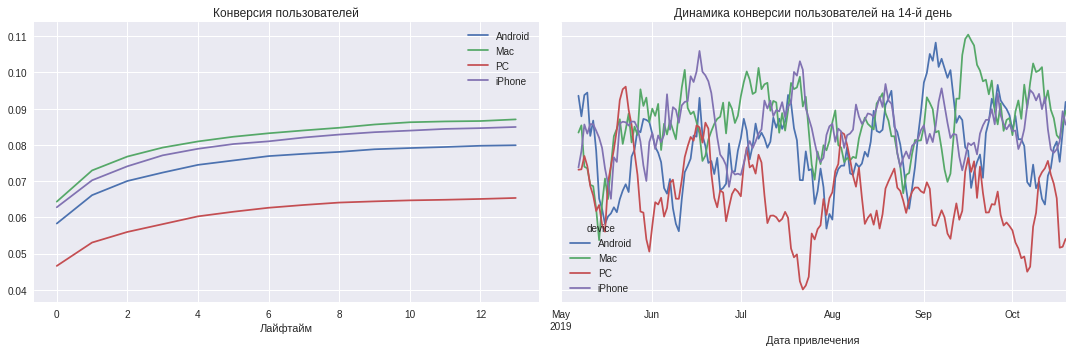

In [44]:
#смотрим конверсию с разбивкой по устройствам
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles, orders, observation_date, horizon_days, dimensions=['device'])
#строим кграфики
plot_conversion(conversion_grouped, conversion_history, horizon_days) 

Судя по графикам, пользователи PC конвертируются заметно хуже, чем пользователи остальных устройств. Динамика конверсии подтвержает данное наблюдение.

Причина окупаемости пользователей PC и неокупаемости остальных все еще не совсем понятна и противоречива. Поэтому надо посмотреть коэффициент удержания.

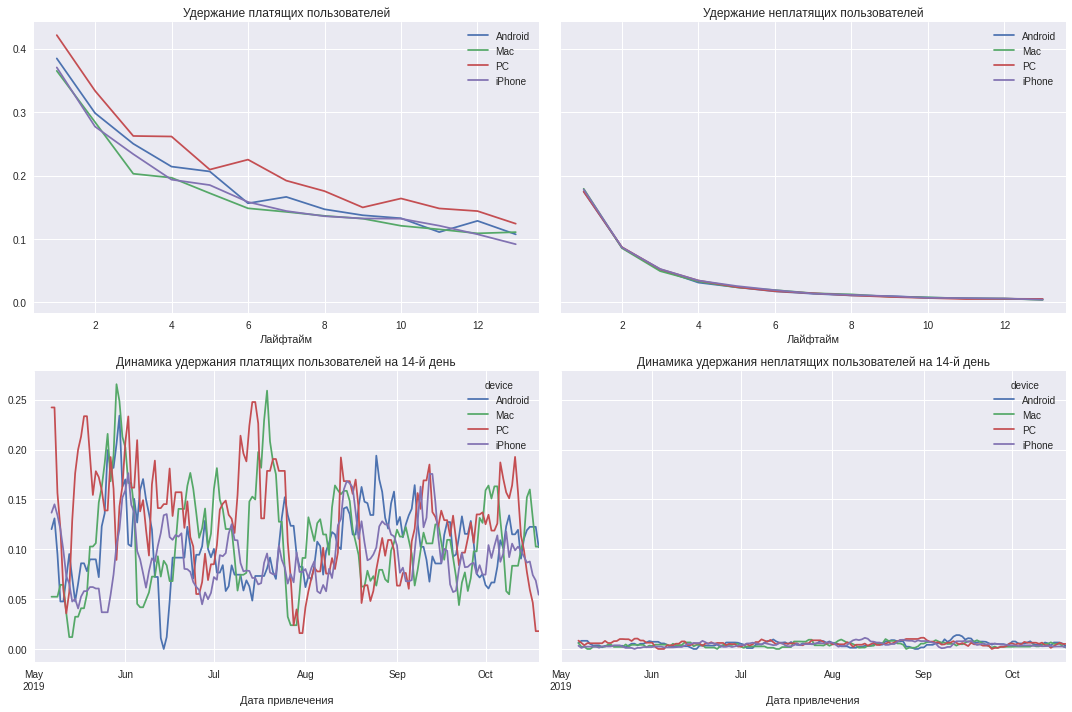

In [45]:
#смотрим удержание с разбивкой по устройствам
retention_raw, retention_grouped, retention_history = get_retention(profiles, visits, observation_date, horizon_days, dimensions=['device'])
#строим графики
plot_retention(retention_grouped, retention_history, horizon_days) 

Платящие пользователи PC с 1го по 14й день удерживаются лучше, чем пользователи других устройств. Возможно эта и есть причина окупаемости этих пользователей.

**Вывод:**
- Самая высокая динамика стоимости привлечения (САС) у пользователей iPhone и Mac. Чуть ниже динамика САС у пользователей Android. Самая низкая, как и предполагалось, у пользователей PC.
- Реклама не окупается ни на одном устройстве, за исключением PC. Реклама для пользователей PC окупается на 11 день, хотя динамика стоимости привлечения пользователей говорит об обратном.
- Динамика ROI в мае-июне кажется более "окупаемой", чем с сентября. Динамика окупаемости пользователей PC имеет более широкий диапазон, чем у пользователей Android, Mac и iPhone. В период с мая по сентябрь окупаемость пользователей PC имеет успех по сравнению с другими устройствами, но с сентября также снижается.
- Пользователи PC конвертируются заметно хуже, чем пользователи остальных устройств, примерно на 25%.
- Платящие пользователи PC с 1го по 14й день удерживаются лучше, чем пользователи других устройств.
- Можно предположить, что причина неокупаемости рекламы не связано с устройствами пользователей.

#### Окупаемость рекламы с разбивкой по странам

Расчитаем LTV, CAC, ROI и их динамику с разбивкой по странам. Пердадим параметру `dimensions` столбец `region`.

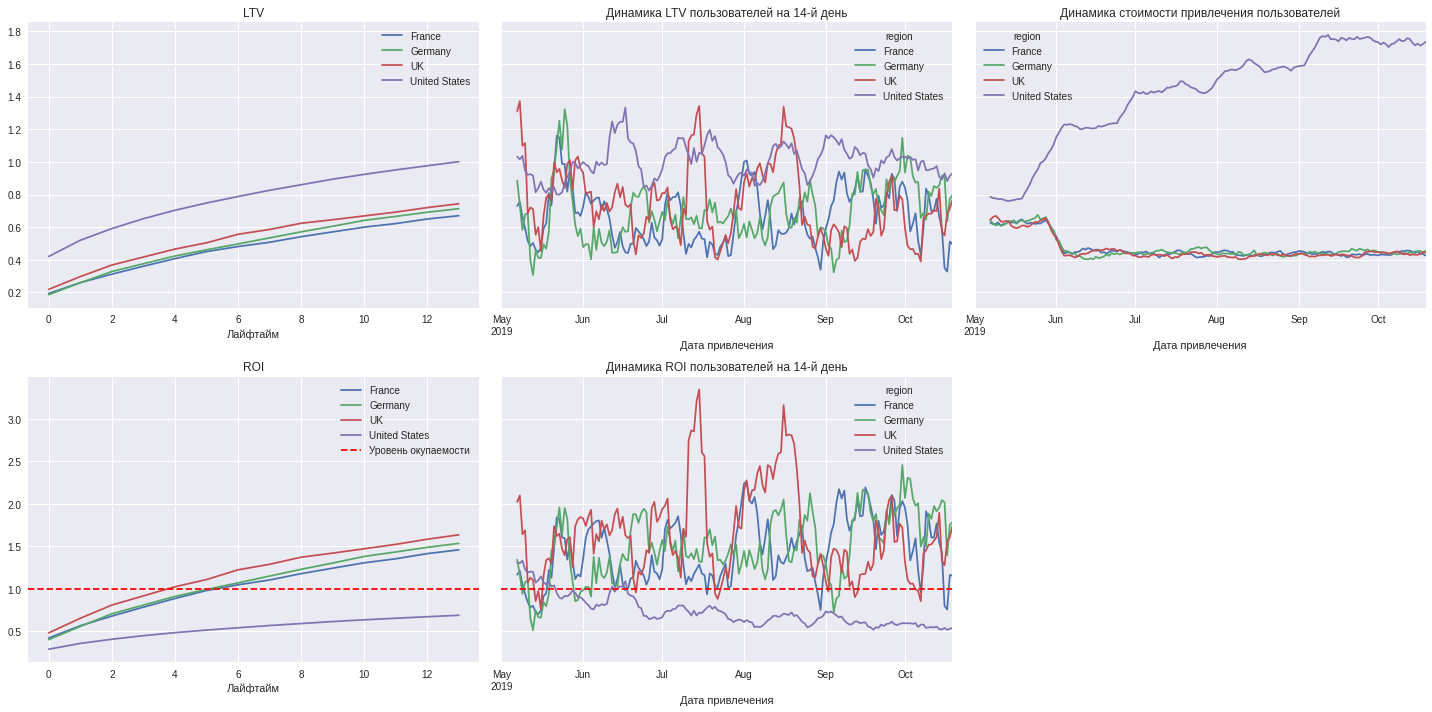

In [46]:
#смотрим окупаемость с разбивкой по странам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles, orders, observation_date, horizon_days, dimensions=['region'])
#строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

С разбивкой по странам видим совсем другую картину:
- Реклама окупается во всех европейских странах уже на 4-5 день. А вот в США реклама не окупается вообще.
- Стоимость привлечения в европейских странах резко снижается в начале июня и в дальнейшем остается стабильной для всех есропейских стран. Стоимость привлечения пользователей в США в разы выше, терпит резкий скачок в середине мая и продолжает увеличиваться.
- LTV в целом стабилен для всех стран. При этом в США LTV выше в 2 раза по сравнению с европейскими странами и на 14 день достигает 1 - что является очень хорошим показателем.

В целом очень странно, почему при больших вложениях в рекламу и хорошем коэффициенте LTV, реклама в США не окупается. Попробуем это исследовать.

Для этого рассчитаем конверсию пользователей и ее динамику.

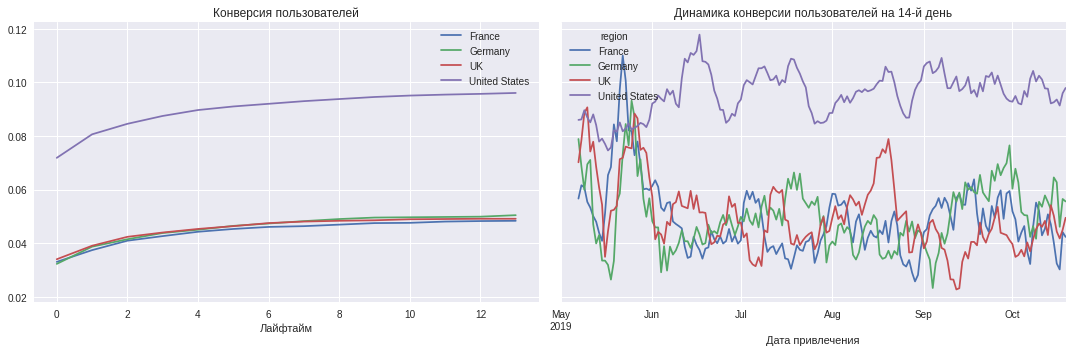

In [47]:
# смотрим конверсию с разбивкой по странам
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles, orders, observation_date, horizon_days, dimensions=['region'])
#строим графики
plot_conversion(conversion_grouped, conversion_history, horizon_days) 

Конверсия пользователей из США в 2 раза больше по сравнению с европейскими странами и на 14й день почти достигает 10%. Динамика конверсии европейских стран с середины мая начинает резкое снижение и дальше держится стабильно, в то время как динамика конверсии пользователей США держится высоко на протяжении всего наблюдаемого периода.

Это очень хороший показатель для США. И причина неокупаемости рекламы не в нем. Нужно проверить удержание.

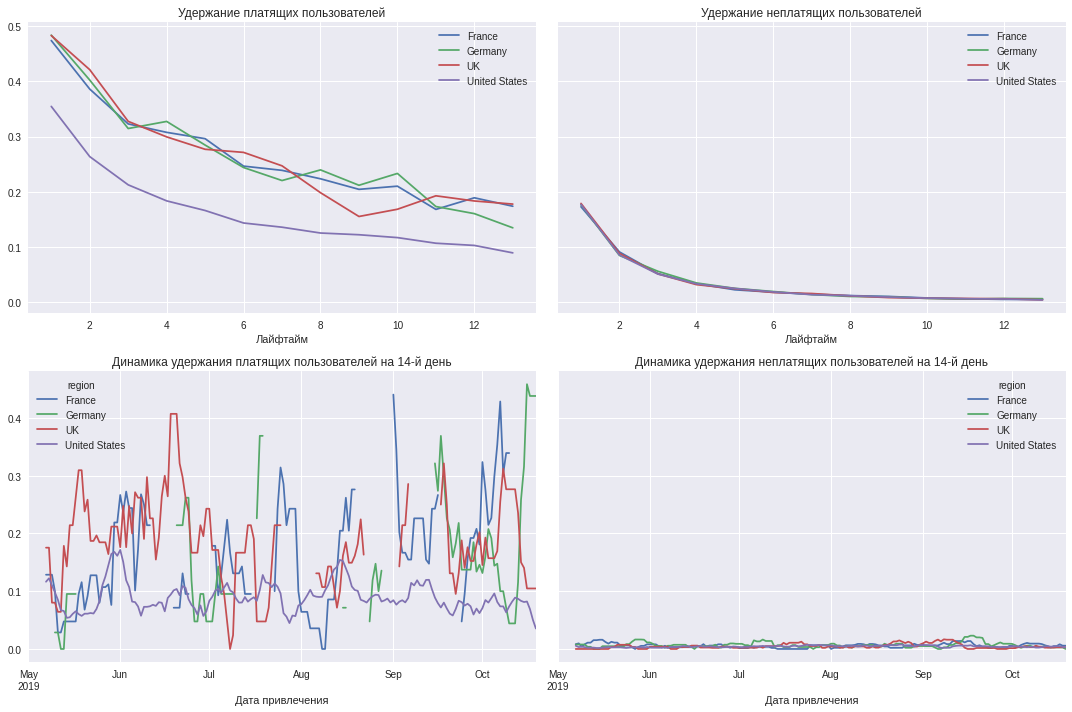

In [48]:
#смотрим удержание с разбивкой по странам
retention_raw, retention_grouped, retention_history = get_retention(profiles, visits, observation_date, horizon_days, dimensions=['region'])
#строим графики
plot_retention(retention_grouped, retention_history, horizon_days) 

Несмотря на хороший показатель конверсии, платящие пользователи из США удерживаются хуже европейских пользователей. На 14й день удержание пользователей из США составило всего около 9%, в то время как у пользователей из Великобритании и Франции этот показатель составил около 19%, что в 2 раза выше.

**Вывод:**
- Реклама окупается во всех странах, за исключением *США*.
- *Стоимость привлечения пользователей в США в разы выше*, терпит резкий скачок в середине мая и продолжает увеличиваться, в то время как в европейских странах этот показатель снижается и остается низким.
- LTV в целом стабилен для всех стран. При этом *в США LTV выше в 2 раза* по сравнению с европейскими странами и на 14 день достигает 1.
- *Конверсия пользователей из США в 2 раза больше* по сравнению с европейскими странами и на 14й день почти достигает 10%.
- На 14й день *удержание платящих пользователей из США составило всего около 9%*, в то время как у пользователей из *Великобритании и Франции* этот показатель составил около *19%*, что в 2 раза выше. Удержание неплатящих пользователей всех стран стабильно снижается и на 14й день практически достигает 0.
- В ходе анализа обнаружили проблему с удержанием платящих пользователей приложения из США. С чем это может быть связано непонятно, скорее всего нам нужны дополнительные данные (например, данные с событиями) для проведения еще более детального исследования.

#### Окупаемость рекламы с разбивкой по рекламным каналам

Расчитаем LTV, CAC, ROI и их динамику с разбивкой по каналам привлечения. Пердадим параметру `dimensions` столбец `channel`.

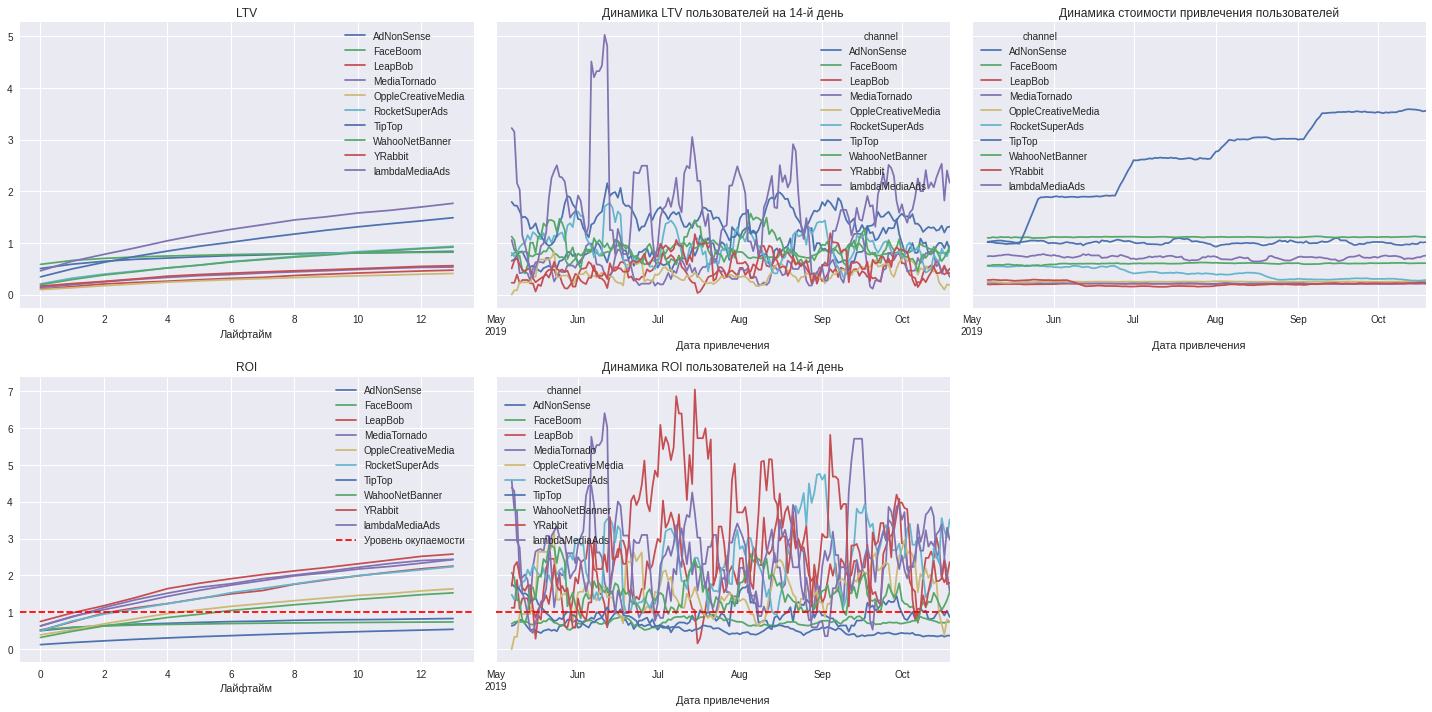

In [49]:
#смотрим окупаемость с разбивкой по рекламным каналам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles, orders, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

Из 10ти рекламных каналов окупаются 7. Каналы *LeapBob*, *MediaTornado*, *lambdaMediaAds*, *YRabbit* и *RocketSuperAds* окупаются уже на 2й-3й день. На 14й день ROI этих каналов достигает примерно 2,5. Каналы *OppleCreativeMedia* и *FaceBoom* начинают окупаться с 5го дня и на 14й день ROI достигает 1,5. Каналы *TipTop*, *WahooNetBanner* и *AdNonSense* вообще не окуапются. Самым окупающимся каналом привлечения оказался *LeapBob*.

Произведем расчет конверсии пользователей и ее динамику с разбивкой по каналам привлечения.

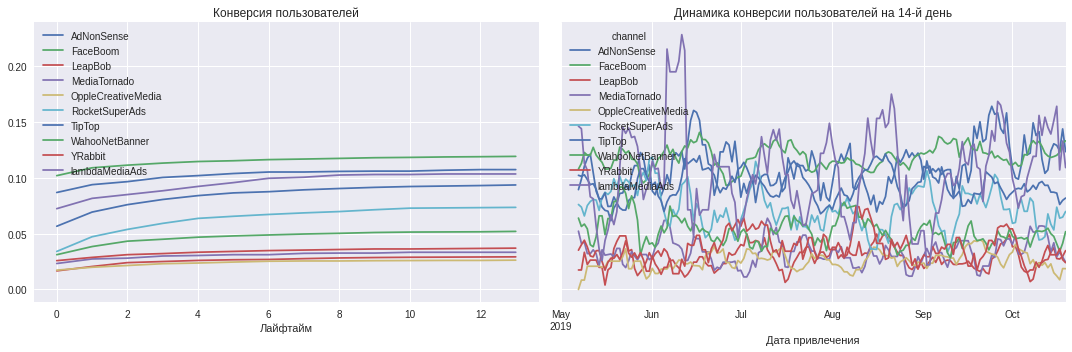

In [50]:
#смотрим конверсию с разбивкой по каналам привлечения
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles, orders, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_conversion(conversion_grouped, conversion_history, horizon_days) 

Лучше всего помогают конвертировать пользователей каналы *FaceBoom* и *TipTop*, их конверсия высока, к 14му дню достигает 11% и 12%, и при этом стабильна. Конверсия *lambdaMediaAds* также высока (около 10%), но при этом не так стабильна в динамике, как предыдущий каналы.

Проверим удержание пользователей в приложении с разбивкой по каналам привлечения.

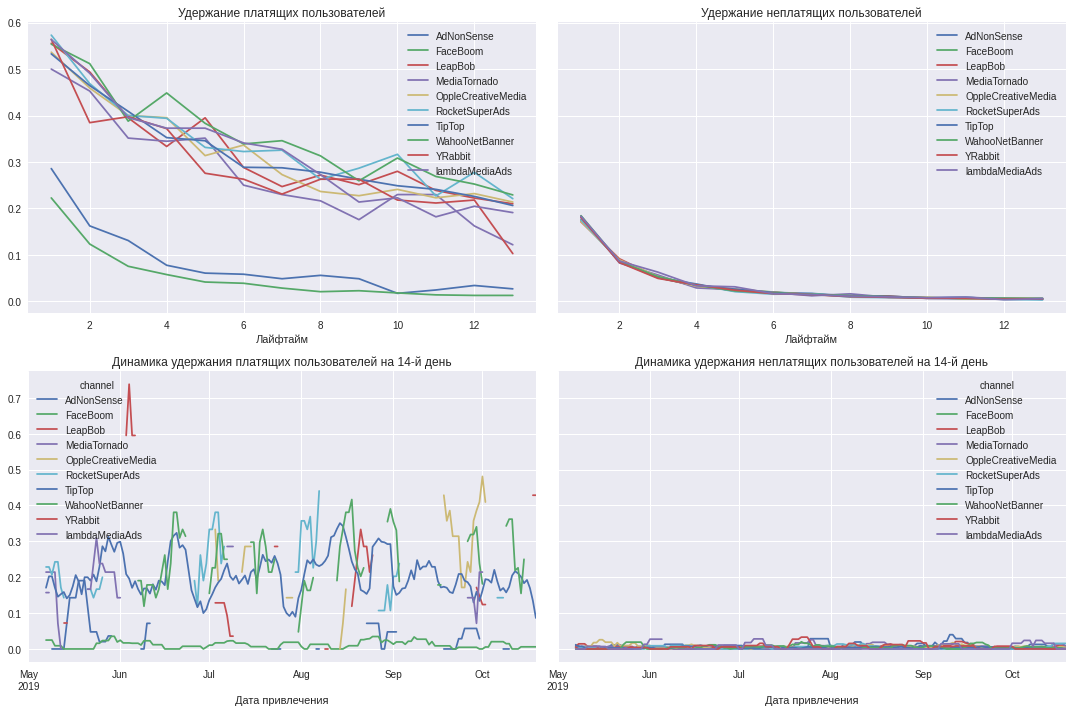

In [51]:
#смотрим удержание с разбивкой по каналам привлечения
retention_raw, retention_grouped, retention_history = get_retention(profiles, visits, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_retention(retention_grouped, retention_history, horizon_days) 

Платящие пользователи, приходящие с каналов *AdNonSense* и *TipTop*, удерживаются гораздо хуже пользователей, пришедших с других каналов привлечения. Их удержание на 14й день составляет 1-2%, что очень мало.

Лучшие показатели по удержанию пользователей показывают каналы *FaceBoom*, *RocketSuperAds*, *OppleCreativeMedia*, *WahooNetBanner*, *LeapBob* и *lambdaMediaAds* - около 20% пользователей на 14й день. Немного хуже и с резкой динамикой к снижению на 14й день показали себя каналы *MediaTornado* и *YRabbit* - 12% пользователей.

Для того, чтобы сделать окончательные выводы, посмотрим окупаемость рекламы с разбивкой по каналам и странам привлечения совместно.

Проверим окупаемость каналов привлечения в США.

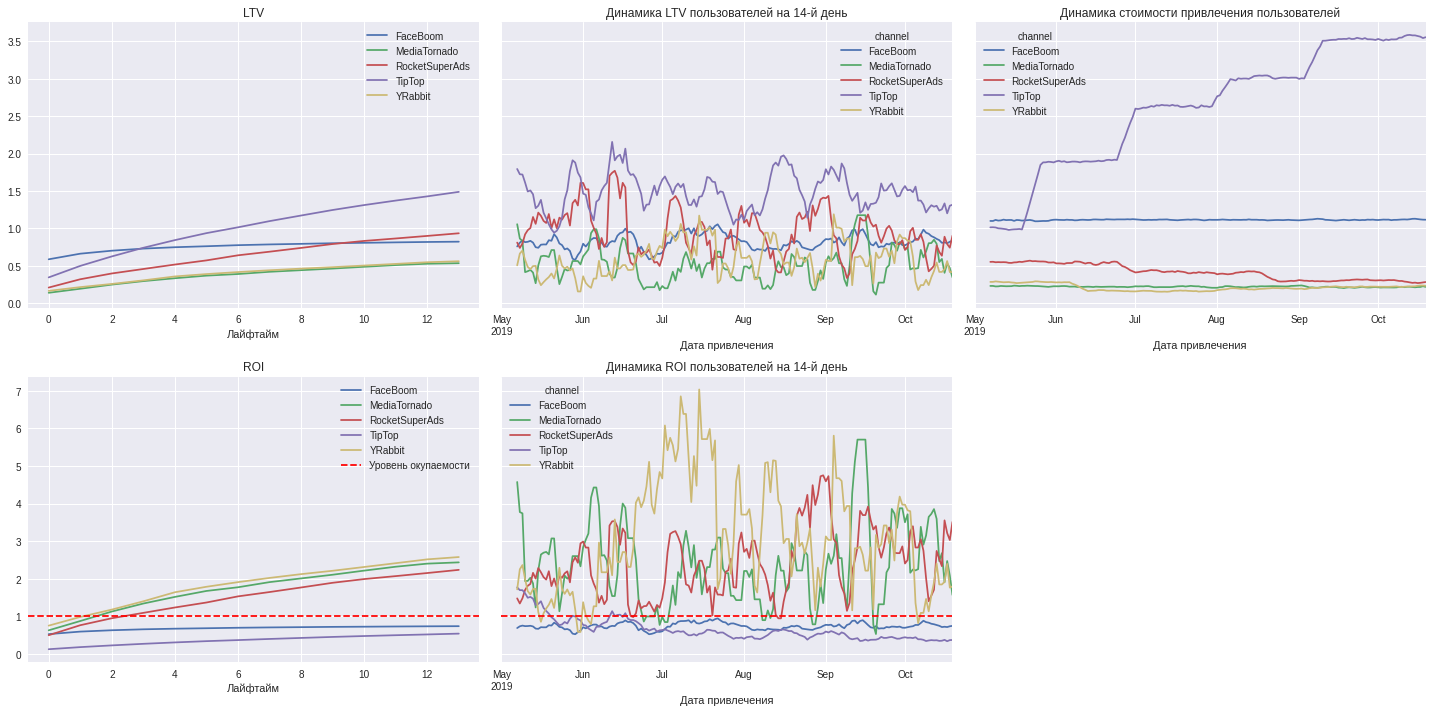

In [52]:
#выделим профили пользователей США
usa_profiles = profiles.query('region == "United States"')
#смотрим окупаемость в США с разбивкой по рекламным каналам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(usa_profiles, orders, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

В США работают 5 каналов привлечения: *FaceBoom*, *MediaTornado*, *RocketSuperAds*, *TipTop* и *Yrabbit*. При этом видим, что каналы *FaceBoom* и *TipTop* не окупаются, в то время как остальные каналы окупаются уже на 2 день. При этом стоимость привлечения на канале *TipTop* резко вырастает с середины мая и в течение всего периода остается самой высокой. Также можно отметить, что LTV пользователей привлеченных каналом *TipTop* почти в 2 раза превышает остальные каналы.

Исследуем конверсию пользователей США по каналам привлечения.

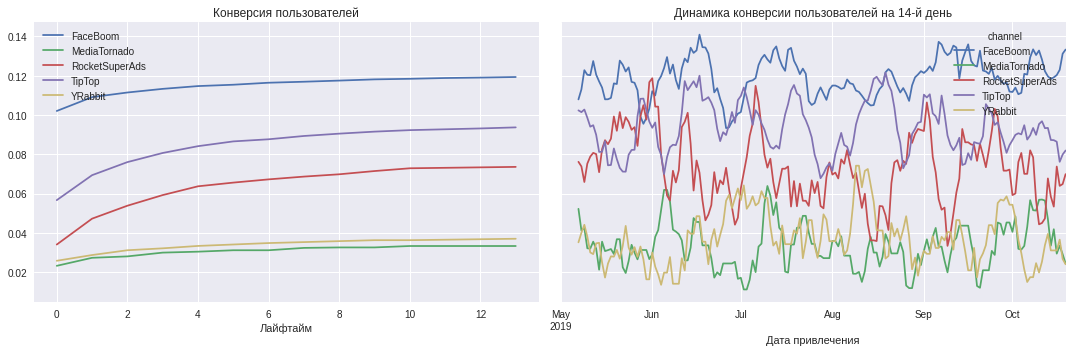

In [53]:
#смотрим конверсию в США с разбивкой по каналам привлечения
conversion_raw, conversion_grouped, conversion_history = get_conversion(usa_profiles, orders, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_conversion(conversion_grouped, conversion_history, horizon_days) 

Лучше всего пользователи США конвертируются из канала *FaceBoom*, их конверсия достаточно стабильна, на первый день составляет 10%, а на 14 - 12%. Чуть хуже конвертируются пользователи из каналов *TipTop* и *RocketSuperAds* - 9% и 7% соответственно. Хуже всего конвертируются пользователи из *YRabbit* и *MediaTornado* - около 3,5%.

Исследуем удержание пользователей США по каналам привлечения.

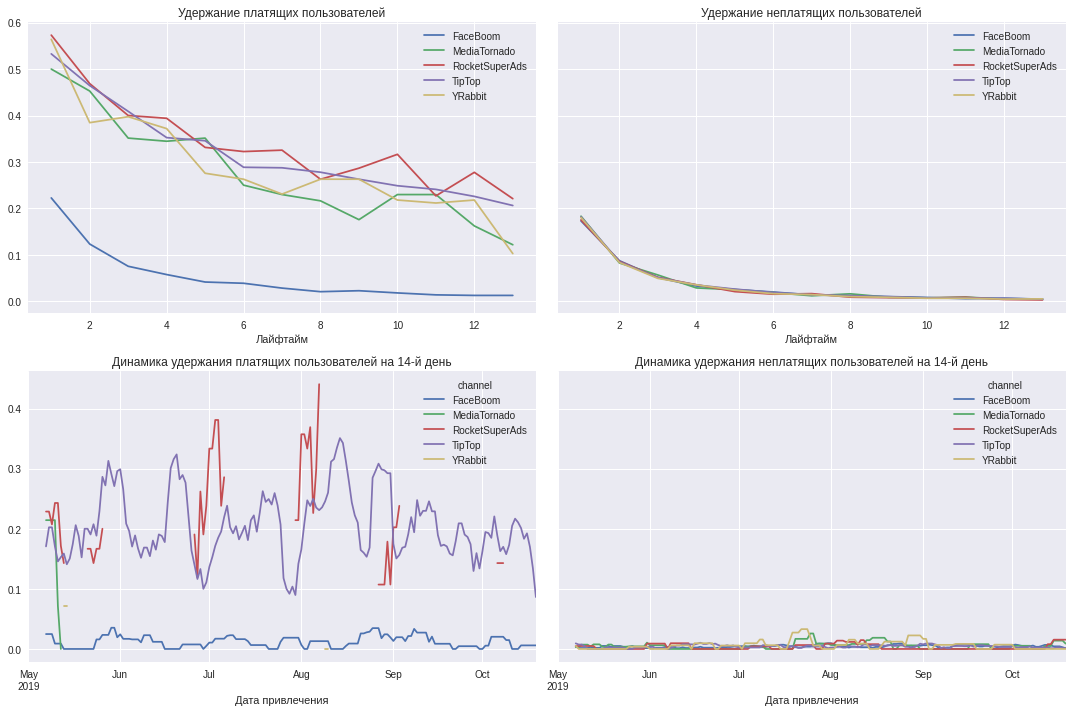

In [54]:
#смотрим удержание в США с разбивкой по каналам привлечения
retention_raw, retention_grouped, retention_history = get_retention(usa_profiles, visits, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_retention(retention_grouped, retention_history, horizon_days) 

Несмотря на высокую конверсию пользователей из *FaceBoom*, удерживаются они очень слабо - около 1%. Лучшее удержание пользователей на 14 день показывают каналы *RocketSuperAds* и *TipTop* - более 20%, что очень хороший показатель!

Теперь посмотрим, как обстоят дела с окупаемостью каналов привлечения в странах Европы.

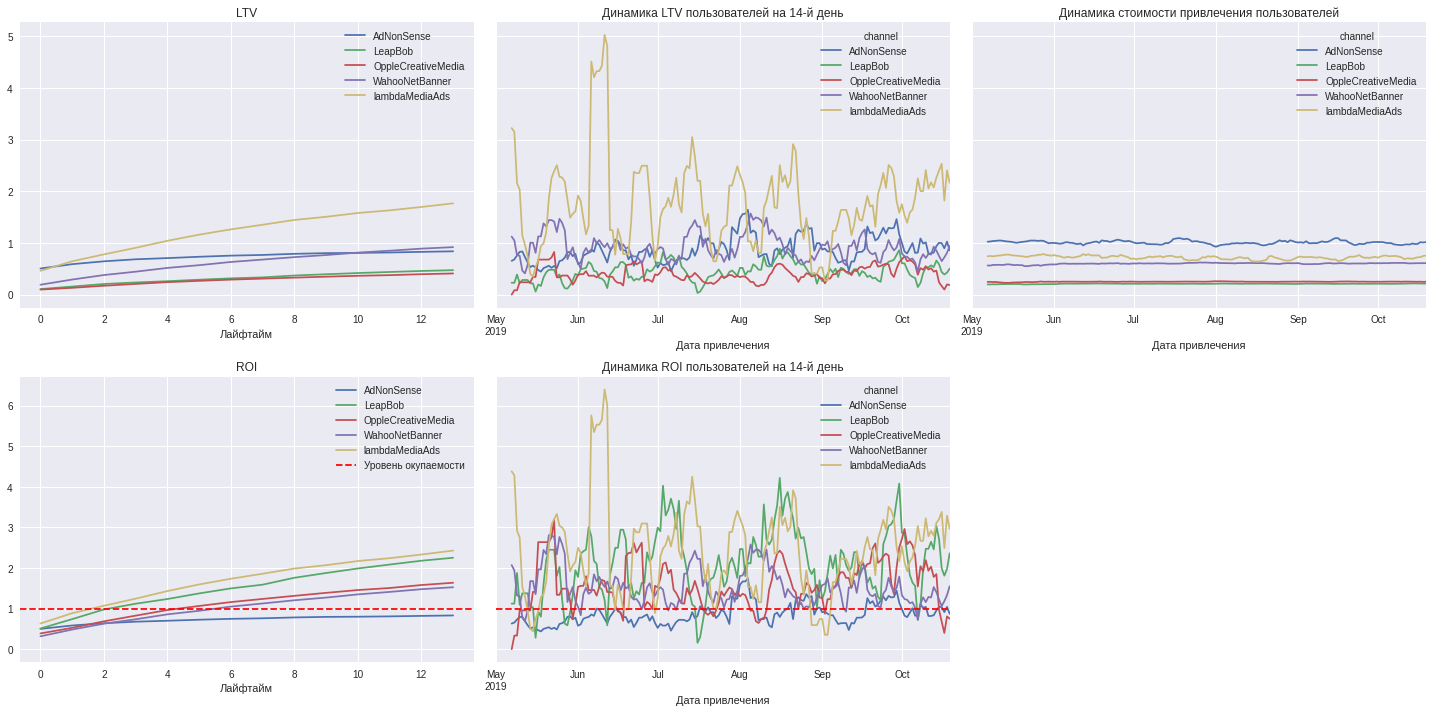

In [55]:
#выделим профили европейских пользователей
euro_profiles = profiles.query('region != "United States"')
#смотрим окупаемость в США с разбивкой по рекламным каналам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(euro_profiles, orders, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

В Европе также работают 5 каналов привлечения: *AdNonSense*, *LeapBob*, *OppleCreativeMedia*, *WahooNetBanner* и *lambdaMediaAds*. Не окупается в Европе лишь 1 канал - *AdNonSense*. *LeapBob* и *lambdaMediaAds* окупаются уже на 2 день, а *OppleCreativeMedia* и *WahooNetBanner* - на 5 день. Самый вымокий LTV у *lambdaMediaAds*, к 14 дню он достигает 1,8. Динамика стоимости привлечения у всех каналов относительно стабильна.

Исследуем конверсию пользователей из Европы по каналам привлечения.

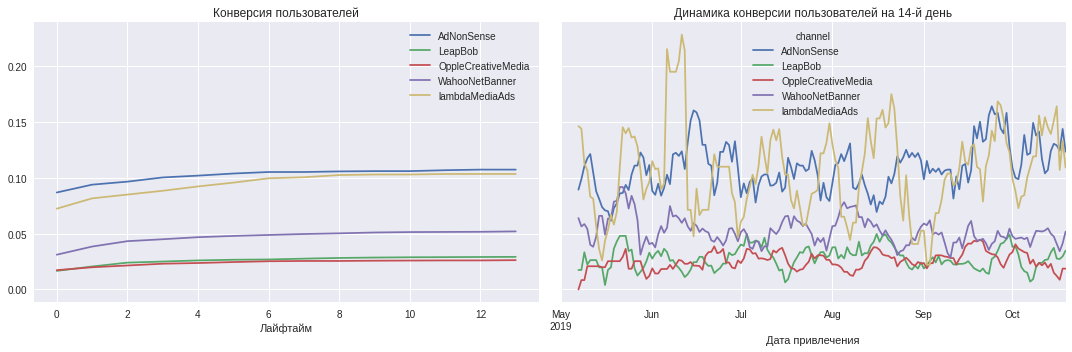

In [56]:
#смотрим конверсию в Европе с разбивкой по каналам привлечения
conversion_raw, conversion_grouped, conversion_history = get_conversion(euro_profiles, orders, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_conversion(conversion_grouped, conversion_history, horizon_days) 

Лучшую конверсию пользователей нам показывают 2 канала - *AdNonSense* и *lambdaMediaAds*. На 14 день конверсия пользователей, пришедших с этих каналов, составляет примерно 11%. Меньше всего конвертируются пользователи из *LeapBob* и *OppleCreativeMedia* - около 3%.

Исследуем удержание европейских пользователей по каналам привлечения.

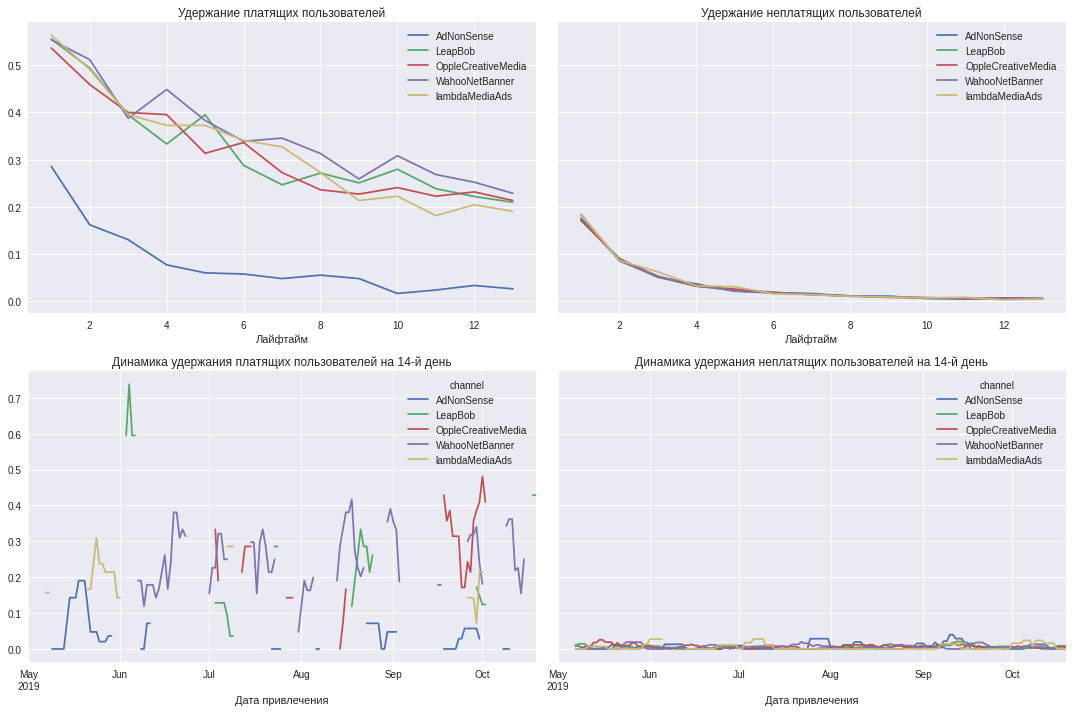

In [57]:
#смотрим удержание в Европы с разбивкой по каналам привлечения
retention_raw, retention_grouped, retention_history = get_retention(euro_profiles, visits, observation_date, horizon_days, dimensions=['channel'])
#строим графики
plot_retention(retention_grouped, retention_history, horizon_days) 

Очень интересная картина! Самый дорогой канал с высокой конверсией *AdNonSense* имеет самое низкое удержание пользователей на 14 день - около 3%. Неудивительно, что он не окупается. Остальные каналы привлечения показывают относительно неплохие результаты по удержанию пользователей - в области 20% на 14 день.

**Вывод:**
- Окупаются 7 каналов привлечения пользователей. Каналы *LeapBob*, *MediaTornado*, *lambdaMediaAds*, *YRabbit* и *RocketSuperAds* окупаются уже на 2й-3й день. На 14й день ROI этих каналов достигает примерно 2,5. Каналы *OppleCreativeMedia* и *FaceBoom* начинают окупаться с 5го дня и на 14й день ROI достигает 1,5. Каналы *TipTop*, *WahooNetBanner* и *AdNonSense* вообще не окуапются.
- Самая высокая динамика стоимости привлечения пользователей у канала *TipTop*. У остальных каналов она в разы ниже и более стабильна.
- Лучшая конверсия пользователей у каналов *FaceBoom* и *TipTop*, их конверсия высока, к 14му дню достигает 11% и 12%, и при этом стабильна. Конверсия *lambdaMediaAds* также высока (около 10%), но при этом не так стабильна в динамике, как предыдущий каналы.
- Удержание пользователей из каналов *AdNonSense* и *TipTop*  самое низкое и составляет 1-2%. Лучшие показатели по удержанию пользователей показывают каналы *FaceBoom*, *RocketSuperAds*, *OppleCreativeMedia*, *WahooNetBanner**, *LeapBob* и *lambdaMediaAds* - около 20% пользователей на 14й день.
- В США работают 5 каналов привлечения: *FaceBoom*, *MediaTornado*, *RocketSuperAds*, *TipTop* и *Yrabbit*. При этом видим, что каналы *FaceBoom* и *TipTop* не окупаются, в то время как остальные каналы окупаются уже на 2 день. При этом стоимость привлечения на канале *TipTop* резко вырастает с середины мая и в течение всего периода остается самой высокой. Также можно отметить, что LTV пользователей привлеченных каналом *TipTop* почти в 2 раза превышает остальные каналы. Лучше всего пользователи США конвертируются из канала *FaceBoom*, их конверсия достаточно стабильна, на первый день составляет 10%, а на 14 - 12%. Чуть хуже конвертируются пользователи из каналов *TipTop и RocketSuperAds* - 9% и 7% соответственно. Хуже всего конвертируются пользователи из *YRabbit и MediaTornado* - около 3,5%. Несмотря на высокую конверсию пользователей из *FaceBoom*, удерживаются они очень слабо - около 1%. Лучшее удержание пользователей на 14 день показывают каналы *RocketSuperAds и TipTop* - более 20%.
- В Европе также работают 5 каналов привлечения: *AdNonSense*, *LeapBob*, *OppleCreativeMedia*, *WahooNetBanner* и *lambdaMediaAds*. Не окупается в Европе лишь 1 канал - *AdNonSense*. *LeapBob* и *lambdaMediaAds* окупаются уже на 2 день, а *OppleCreativeMedia* и *WahooNetBanner* - на 5 день. Самый вымокий LTV у *lambdaMediaAds*, к 14 дню он достигает 1,8. Динамика стоимости привлечения у всех каналов относительно стабильна. Лучшую конверсию пользователей нам показывают 2 канала - *AdNonSense* и *lambdaMediaAds*. На 14 день конверсия пользователей, пришедших с этих каналов, составляет примерно 11%. Меньше всего конвертируются пользователи из *LeapBob* и *OppleCreativeMedia* - около 3%. Самый дорогой канал с высокой конверсией *AdNonSense* имеет самое низкое удержание пользователей на 14 день - около 3%. Неудивительно, что он не окупается. Остальные каналы привлечения показывают относительно неплохие результаты по удержанию пользователей - в области 20% на 14 день.

**Вывод по разделу:**

- В целом рекламная кампания приложения `Procrastinate Pro+` не окупается. ROI составляет 80% в конце 2 недели. Динамика общей конверсии в целом стабильна. Темп конверсии средний. Общий коэффициент удержания платящих пользователей стабильно выше, чем у неплатящих, от начала и до конца исследуемого периода, причем примерно в 2 раза. Платящие пользователи с большей вероятностью и далее останутся в приложении, в то время как неплатящие скорее всего уйдут. Активность платящих пользователей в отличие от неплатящих очень хорошо отражена на графиках динамики. У неплатящих пользователей показатель динамики близок к 0.
- С разбивкой по устройствам видим, что реклама окупается только для пользователей, пользующихся PC, при этом их конверсия ниже, чем у остальных устройств, но удержание пользователей лучше. На это стоит обратить внимание! В целом, на наш взгляд, причины неэффективности привлечения пользователей в меньшей степени связаны с устройством пользователя.
- Исследуя страны, можем сказать, что, несмотря на то, что большая часть пользователей приложения находятся в США, реклама в этой стране не окупается, по сравнению с Францией, Германией и Великобританией. При этом в США очень хорошая конверсия, которая достигает 10% и в разы больше, чем в других странах. Это может быть связано с тем, что отдел маркетинга увеличил финансирование рекламы в этой стране и снизил его в других странах с июня. Что примечательно - удержание пользователей в США намного ниже, чем в странах Европы!
- В общей картине окупаются 7 каналов привлечения пользователей. Каналы *LeapBob*, *MediaTornado*, *lambdaMediaAds*, *YRabbit* и *RocketSuperAds* окупаются уже на 2й-3й день. На 14й день ROI этих каналов достигает примерно 2,5. Каналы *OppleCreativeMedia* и *FaceBoom* начинают окупаться с 5го дня и на 14й день ROI достигает 1,5. Каналы *TipTop*, *WahooNetBanner* и *AdNonSense* совсем не окуапются. Больше всего финансов маркетологи с середины мая закладывали в канал *TipTop* - 3,5 денежные единицы/пользователя к концу 2 недели, финансирование остальных каналов было стабильным. Лучшая конверсия пользователей у каналов *FaceBoom*, *TipTop* и *lambdaMediaAds*, она достигает 11%, 12% и 10% соответственно.Удержание пользователей из каналов *AdNonSense* и *TipTop*  самое низкое и составляет 1-2%. Лучшие показатели по удержанию пользователей показывают каналы *FaceBoom*, *RocketSuperAds*, *OppleCreativeMedia*, *WahooNetBanner**, *LeapBob* и *lambdaMediaAds* - около 20% пользователей на 14й день.
- В США работают 5 каналов привлечения: *FaceBoom*, *MediaTornado*, *RocketSuperAds*, *TipTop* и *Yrabbit*. При этом видим, что каналы *FaceBoom* и *TipTop* не окупаются, в то время как остальные каналы окупаются уже на 2 день. При этом стоимость привлечения на канале *TipTop* резко вырастает с середины мая и в течение всего периода остается самой высокой. Также можно отметить, что LTV пользователей привлеченных каналом *TipTop* почти в 2 раза превышает остальные каналы. Лучше всего пользователи США конвертируются из канала *FaceBoom*, их конверсия достаточно стабильна, на первый день составляет 10%, а на 14 - 12%. Чуть хуже конвертируются пользователи из каналов *TipTop и RocketSuperAds* - 9% и 7% соответственно. Хуже всего конвертируются пользователи из *YRabbit и MediaTornado* - около 3,5%. Несмотря на высокую конверсию пользователей из *FaceBoom*, удерживаются они очень слабо - около 1%. Лучшее удержание пользователей на 14 день показывают каналы *RocketSuperAds и TipTop* - более 20%.
- В Европе также работают 5 каналов привлечения: *AdNonSense*, *LeapBob*, *OppleCreativeMedia*, *WahooNetBanner* и *lambdaMediaAds*. Не окупается в Европе лишь 1 канал - *AdNonSense*. *LeapBob* и *lambdaMediaAds* окупаются уже на 2 день, а *OppleCreativeMedia* и *WahooNetBanner* - на 5 день. Самый вымокий LTV у *lambdaMediaAds*, к 14 дню он достигает 1,8. Динамика стоимости привлечения у всех каналов относительно стабильна. Лучшую конверсию пользователей нам показывают 2 канала - *AdNonSense* и *lambdaMediaAds*. На 14 день конверсия пользователей, пришедших с этих каналов, составляет примерно 11%. Меньше всего конвертируются пользователи из *LeapBob* и *OppleCreativeMedia* - около 3%. Самый дорогой канал с высокой конверсией *AdNonSense* имеет самое низкое удержание пользователей на 14 день - около 3%. Неудивительно, что он не окупается. Остальные каналы привлечения показывают относительно неплохие результаты по удержанию пользователей - в области 20% на 14 день.
- Осмелимся предположить, что причинами неэффективности привлечения пользователей могла стать неверная ориентация рекламной кампании и неверный выбор финансирования каналов привлечения пользователей. Исходя из исследования, можно обратить внимание на европейские страны, так как окупаемость рекламы и удержание пользователей там достаточно хорошее. А также сменить финансирование каналов привлечения пользователей.

### Выводы и рекомендации

**Сделав исследование проведения рекламных кампаний приложения `Procrastinate Pro+` в период 01.05.2019 - 27.10.2019 можем сформировать следующие выводы:**

66% пользователей приложения Procrastinate Pro+  - граждане США. По доле платящих пользователей также в лидерах остается США с долей 6,9%. Но пользователи из Германии в процентном соотношении чаще становятся платящими, в отличии от Великобритании и Франции.

Большая часть пользователей приложения использует устройства iPhone - таких пользователей 54479. Наименьшее и примерно равное количество пользователей с устройствами PC и Mac - 30455 и 30042 пользователей соответственно. По доли платящих лидируют пользователи Mac - 6,36%. Пользователи PC идут на последнем месте с долей 5,05%.

Компания использовала 11 каналов привлечения. Больше всего привлеклось органических пользователей - их 56439. На втором месте по количеству привлеченных пользователей канал FaceBoom. Доля платящих пользователей привлеченных с FaceBoom самая высокая.

Общая сумма расходов на маркетинг составила 105497.3 денежных единиц.
Предполагаем, что с начала июня компания начала резко увеличивать финансирование рекламных кампаний. Большая часть финансов на рекламу была вложена в каналы привлечения TipTop и FaceBoom - 51,9% и 30,8% соответственно. Меньше всего затрат было на канал YRabbit - 0,9%.

Динамика маркетинговых расходов во времени остается практически неизменной по большинству каналов привлечения. Исключения составляют каналы TipTop и FaceBoom. Их динамика сильно варьируется с тенденцией к повышению. 

Общий САС без разбивки по характеристикам составил 1.13 денежных единиц. Самая высокая средняя стоимость привлечения пользователей у канала TipTop - в среднем 2,8 денежных единиц. Более чем в 2 раза ниже стоимость привлечения на канале FaceBoom - 1,1 денежная единица. Меньше всего стоимость привлечения пользователей на платформах MediaTornado и LeapBob - 0,21 денежная единица. В общем, стоимость привлечения пользователей в приложение у всех каналов ниже средней, кроме канала TipTop - он является самым дорогим.

В целом рекламная кампания приложения Procrastinate Pro+ не окупается. ROI составляет 80% в конце 2 недели. Динамика общей конверсии в целом стабильна. Темп конверсии средний. Общий коэффициент удержания платящих пользователей стабильно выше, чем у неплатящих, от начала и до конца исследуемого периода, причем примерно в 2 раза. Активность платящих пользователей в отличие от неплатящих очень хорошо отражена на графиках динамики. У неплатящих пользователей показатель динамики близок к 0.

Если смотреть по устройствам наблюдаем, что реклама окупается только для пользователей, пользующихся PC, при этом их конверсия ниже, чем у остальных устройств, но удержание пользователей лучше. Судя по нестабильной динамике конверсии пользователей РС, можем предположить, что на каких-то этапах есть неполадки. Эту тему нужно изучить подробнее. Более детальное исследование для подтверждения нашей гипотезы мы сможем провести после того, как получим недостающие данные. Если гипотеза подтвердится, то эту проблему нужно будет передать отделу разработки.

Исследуя страны, можем сказать, что, несмотря на то, что большая часть пользователей приложения находится в США, реклама в этой стране не окупается, по сравнению с Францией, Германией и Великобританией. При этом в США очень хорошая конверсия, которая достигает 10% и в разы больше, чем в других странах. Это может быть связано с тем, что отдел маркетинга увеличил финансирование рекламы в этой стране и снизил его в других странах с июня. Что примечательно - удержание пользователей в США намного ниже, чем в странах Европы! Исходя из этого, стоит предположить, что финансирование рекламы во Франции, Германии и Великобритании стоит увеличить.

Окупаются 7 каналов привлечения пользователей из 10. Каналы LeapBob, MediaTornado, lambdaMediaAds, YRabbit и RocketSuperAds окупаются уже на 2й-3й день. На 14й день ROI этих каналов достигает примерно 2,5. Каналы OppleCreativeMedia и FaceBoom начинают окупаться с 5го дня и на 14й день ROI достигает 1,5. Каналы TipTop, WahooNetBanner и AdNonSense совсем не окуапются. Больше всего финансов маркетологи с середины мая закладывали в канал TipTop - 3,5 денежные единицы/пользователя к концу 2 недели. Финансирование остальных каналов было стабильным. Лучшая конверсия пользователей у каналов FaceBoom, TipTop и lambdaMediaAds, она достигает 11%, 12% и 10% соответственно. Удержание пользователей из каналов AdNonSense и WahooNetBanner самое низкое и составляет 1-2%.
Лучшие показатели по удержанию пользователей показывают каналы FaceBoom, RocketSuperAds, OppleCreativeMedia, TipTop, LeapBob и lambdaMediaAds - около 20% пользователей на 14й день.

В США работают 5 каналов привлечения: *FaceBoom*, *MediaTornado*, *RocketSuperAds*, *TipTop* и *Yrabbit*. При этом видим, что каналы *FaceBoom* и *TipTop* не окупаются, в то время как остальные каналы окупаются уже на 2 день. При этом стоимость привлечения на канале *TipTop* резко вырастает с середины мая и в течение всего периода остается самой высокой. Также можно отметить, что LTV пользователей привлеченных каналом *TipTop* почти в 2 раза превышает остальные каналы. Лучше всего пользователи США конвертируются из канала *FaceBoom*, их конверсия достаточно стабильна, на первый день составляет 10%, а на 14 - 12%. Чуть хуже конвертируются пользователи из каналов *TipTop и RocketSuperAds* - 9% и 7% соответственно. Хуже всего конвертируются пользователи из *YRabbit и MediaTornado* - около 3,5%. Несмотря на высокую конверсию пользователей из *FaceBoom*, удерживаются они очень слабо - около 1%. Лучшее удержание пользователей на 14 день показывают каналы *RocketSuperAds и TipTop* - более 20%.

В Европе также работают 5 каналов привлечения: *AdNonSense*, *LeapBob*, *OppleCreativeMedia*, *WahooNetBanner* и *lambdaMediaAds*. Не окупается в Европе лишь 1 канал - *AdNonSense*. *LeapBob* и *lambdaMediaAds* окупаются уже на 2 день, а *OppleCreativeMedia* и *WahooNetBanner* - на 5 день. Самый вымокий LTV у *lambdaMediaAds*, к 14 дню он достигает 1,8. Динамика стоимости привлечения у всех каналов относительно стабильна. Лучшую конверсию пользователей нам показывают 2 канала - *AdNonSense* и *lambdaMediaAds*. На 14 день конверсия пользователей, пришедших с этих каналов, составляет примерно 11%. Меньше всего конвертируются пользователи из *LeapBob* и *OppleCreativeMedia* - около 3%. Самый дорогой канал с высокой конверсией *AdNonSense* имеет самое низкое удержание пользователей на 14 день - около 3%. Неудивительно, что он не окупается. Остальные каналы привлечения показывают относительно неплохие результаты по удержанию пользователей - в области 20% на 14 день.

Предполагаем, что причинами неэффективности привлечения пользователей могла стать неверная ориентация рекламной кампании и неверное распределение бюджета на каналы привлечения пользователей.

**Рекомендации:**
1. Обратить внимание и начать больше ориентировать рекламную кампанию на европейские страны: Германия, Великобритания, Франция. В этих странах хороший процент удержания пользователей, а также реклама там окупается. Можно попробовать рассмотреть также и другие европейские страны с платежеспособным населением.
2. Стоит пересмотреть распределение финансов на каналы привлечения пользователей. 
  - В США самым финансируемым каналом является TipTop у него неплохая конверсия и удержание, но канал не окупается. Вторым по финансируемости идет канал FaceBoom с лучшей конверсией, но удержанием пользователей в 1%. Этот канал также не окупается. На наш взгяд, финансирование каналов TipTop и FaceBoom необходимо сократить, но отказываться от рекламы на них не стоит - все-таки оттуда приходит большое количество платящих пользователей. В рамках рынка США очень интересен канал RocketSuperAds - у него неплохая конверсия и прекрасный процент удержания пользователей, канал прекрасно окупается. Маркетологам следует обратить на него внимание и рассмотреть возможность увеличения финансирования рекламы в нем.
  - В Европе больше всего финансов компания закладывает в канал AdNonSense. Канал приводит много пользователей, которые очень хорошо конвертируются, но удерживаются достаточно слабо - 3%. Канал не окупается! Можно снизить распределение бюджета на этот канал. Обратить свое внимание здесь стоит на канал lambdaMediaAds. Пользователи из этого канала приносят больше всего денег компании, прекрасно конвертируются и удерживаются на уровне 20%.